**Прогнозування підписки на банківський депозит**

Даний проєкт присвячений розробці моделі машинного навчання для передбачення результатів маркетингової кампанії банківської установи.

Основна мета — класифікувати клієнтів за їхньою схильністю до оформлення строкового депозиту на основі соціально-демографічних показників та історії взаємодії з банком.

Етапи реалізації проєкту:
* EDA: дослідження впливу характеристик клієнтів, даних про маркетингову кампанію та зовнішніх економічних факторів на цільову змінну.
* Препроцесинг та інженерія ознак: створення пайплайнів для обробки категоріальних даних та масштабування числових ознак.
* Моделювання: порівняльний аналіз п'яти типів алгоритмів: логістичної регресії, методу k-найближчих сусідів (kNN), дерев рішень, XGBoost та LightGBM.
* Оптимізація та підбір гіперпараметрів: використання байєсівської оптимізації (Hyperopt) та випадкового пошуку (Randomized Search) для покращення якості фінальної моделі.
* Інтерпретація результатів: аналіз важливості ознак за допомогою бібліотеки SHAP та Error Analysis для визначення випадків, у яких модель припускається помилок, з метою подальшого вдосконалення алгоритму.

# Імпорти

In [1]:
import sys

# Якщо pkg_resources відсутній, ми створюємо його "заглушку"
try:
    import pkg_resources
except ImportError:
    import pip._vendor.pkg_resources as pkg_resources
    sys.modules["pkg_resources"] = pkg_resources

print("Проблема з pkg_resources вирішена через внутрішній вендор pip!")

Проблема з pkg_resources вирішена через внутрішній вендор pip!


In [2]:
import pandas as pd
import numpy as np

import os

import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore', category=UserWarning)

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score

from sklearn.metrics import f1_score, classification_report

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

from lightgbm import LGBMClassifier

import shap

from IPython.display import display

from src.eda_utils import eda_category, eda_numeric
from src.pipelines import create_preprocessor, create_pipeline, evaluate_model, prepare_data, save_results

In [3]:
os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Exploratory Data Analysis

## Попередній аналіз

In [4]:
# зчитування і перегляд даних
raw_df = pd.read_csv(
    "../data/bank-additional-full.csv",
    sep=";"
)
display(raw_df)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [5]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
raw_df.describe().round(2)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [7]:
# співвідношення класів цільової змінної
(raw_df['y'].value_counts(normalize=True) * 100).round(2)

y
no     88.73
yes    11.27
Name: proportion, dtype: float64

In [8]:
# кількість категоріальних і числових ознак
cat_cols = raw_df.drop(columns=['y']).select_dtypes(include=['object', 'string']).columns
num_cols = raw_df.select_dtypes(include='number').columns

print(f'Кількість категоріальних ознак: {len(cat_cols)}')
print(f'Кількість числових ознак: {len(num_cols)}')

Кількість категоріальних ознак: 10
Кількість числових ознак: 10


* Датасет містить 41888 спостережень та 20 ознак (окрім цільової). Пропуски відсутні.
* Дані містять як числові, так і категоріальні ознаки:
   - числових ознак - 10
   - категоріальних ознак - 10
* Очевидних аномалій або некоректних значень на даному етапі не виявлено.
* Цільова змінна незбалансована: клас 'no' становить ~89%, 'yes' - ~11%.

## Підготовка даних для подальшої роботи

In [9]:
# розбиття даних на тренувальні та валідаційні у співвідношенні 80/20
train_df, val_df = train_test_split(raw_df, test_size=0.2, random_state=42, stratify=raw_df['y'])

In [11]:
train_df = train_df.copy()
val_df = val_df.copy()

# створення колонки відповідності 'yes' = 1, 'no' = 0
train_df['y_num'] = train_df['y'].map({'yes': 1, 'no': 0})
val_df['y_num'] = val_df['y'].map({'yes': 1, 'no': 0})

# створення переліку колонок для подальшої обробки
input_cols = [col for col in train_df.columns if col not in ['y', 'y_num']]

target_col = 'y_num'
target_cat_col = 'y'

## АНАЛІЗ ЗАГАЛЬНИХ ДАНИХ ПРО КЛІЄНТІВ

### Аналіз змінної 'age'

==================== Column: age ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 75
Кількість пропущених значень: 0
Асиметрія даних: 0.76
Викиди: 368
Медіана "no": 38.0
Медіана "yes": 37.0
count    32950.00
mean        40.01
std         10.40
min         17.00
25%         32.00
50%         38.00
75%         47.00
max         98.00
Name: age, dtype: float64


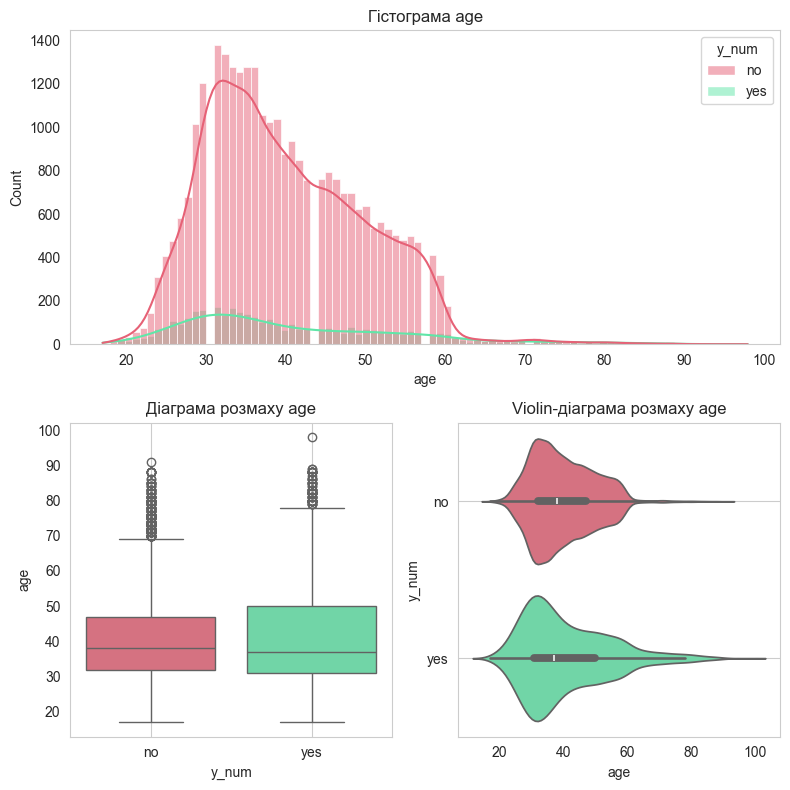

In [16]:
eda_numeric(train_df, 'age', target_col)

* Колонка 'age' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 17 до 98 років, що цілком реалістично.
* Візуалізація даних показує:
   - невелика кількість молодих клієнтів
   - основна маса клієнтів має вік 30-50 років
   - розподіл правоскошений (що підтверджує і асиметрія 0.76)
   - розподіли віку для y='yes' та y='no' доволі схожі

**Гіпотеза:** вік може не стати сильним предиктором для цільової змінної, але може бути корисною ознакою для покращення моделі в цілому.

### Аналіз змінної 'job'
– вид зайнятості (категоріальна змінна)

==================== Column: job ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 12
Кількість пропущених значень: 0


job,admin.,blue-collar,technician,services,management,retired,entrepreneur,self-employed,housemaid,unemployed,student,unknown
value_counts,8314.00,7441.00,5400.00,3196.0,2345.00,1366.00,1160.00,1099.00,855.00,798.00,711.00,265.0
value_percentage,25.23,22.58,16.39,9.7,7.12,4.15,3.52,3.34,2.59,2.42,2.16,0.8


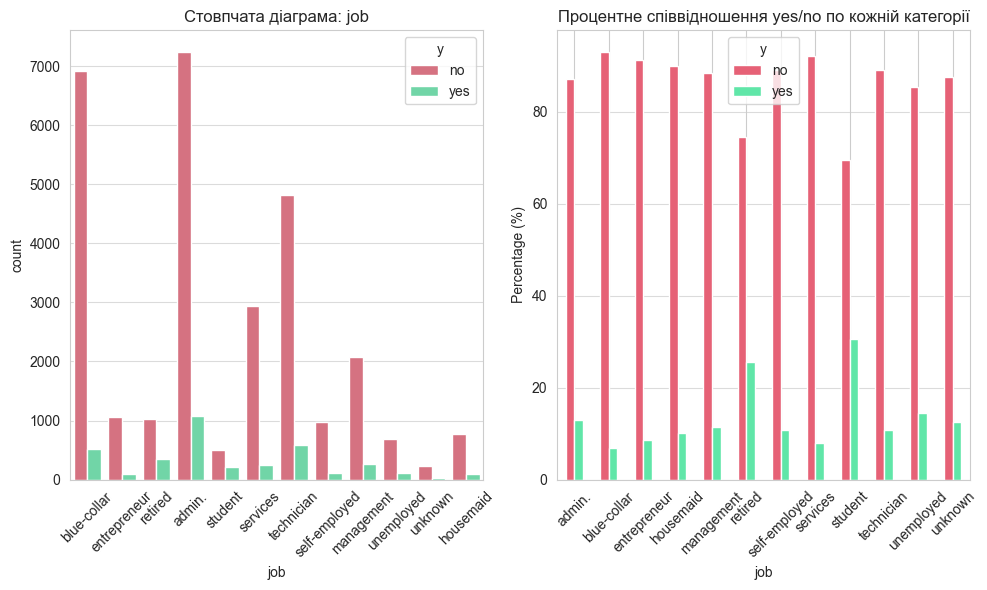

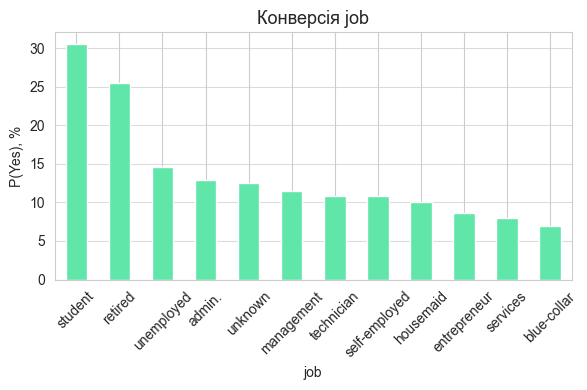

In [17]:
eda_category(train_df, 'job', target_cat_col)

* Колонка 'job' містить 32950 спостережень та 12 унікальних значень, пропуски відсутні.
* Категорії даної ознаки незбалансовані:
  - 64% значень належать до 3-х із 12-ти категорій (admin., blue-collar, technician)
  - 7 із 12-ти категорій мають частку в загальних даних менше 4%
  - категорія 'unknown' містить лише 1% даних
* Візуалізація даних показує:
   - ймовірність позитивної відповіді суттєво відрізняється між категоріями
   - більшість професій слабо відрізняються між собою: 10-14% позитивних відповідей
   - у категорій 'student' та 'retired' ймовірність позитивної відповіді значно вища, ніж у інших

**Гіпотеза:** ознака 'job' є доволі інформативною і може стати корисним предиктором.

### Аналіз змінної 'marital'
– сімейний стан

==================== Column: marital ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 4
Кількість пропущених значень: 0


marital,married,single,divorced,unknown
value_counts,19953.00,9257.00,3675.00,65.0
value_percentage,60.56,28.09,11.15,0.2


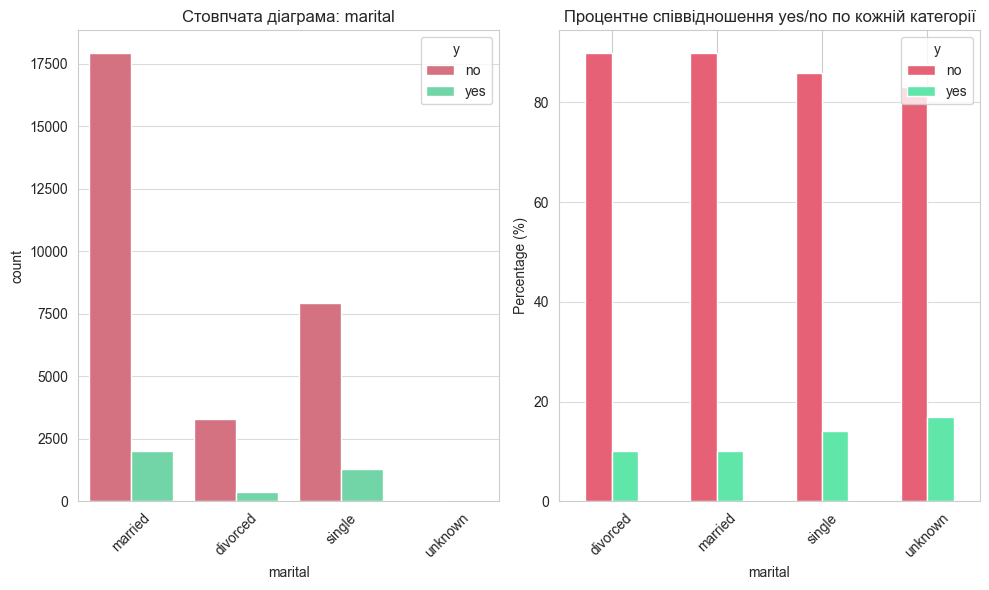

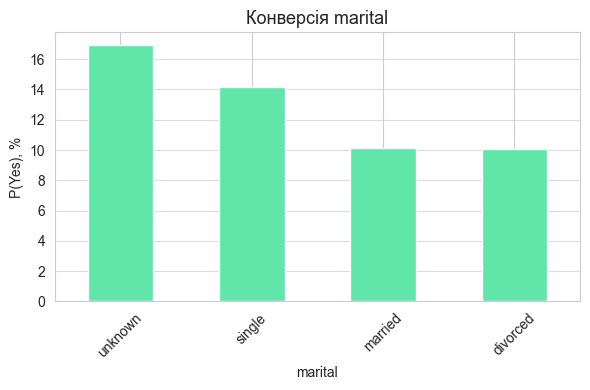

In [18]:
eda_category(train_df, 'marital', target_cat_col)

* Колонка 'marital' містить 32950 спостережень та 4 унікальних значення, пропуски відсутні.
* Категорії даної ознаки незбалансовані:
  - одружені клієнти становлять більшість клієнтів банку: ~61%
  - клієнти з невідомим сімейним станом - 0,2%
* Візуалізація даних показує:
   - частка негативної відповіді в кожній категорії становить понад 80%
   - одинокі клієнти більш схильні до позитивної відповіді
   - категорія 'unknown' має найвищу частку серед позитивних відповідей, але вибірка дуже мала (0,2%), тому дані можуть бути нестабільними

**Гіпотеза:** ознака 'marital' ймовірно не є сильним предиктором, але може дати додаткову інформацію для моделі, бо сімейний стан клієнта може впливати на рішення щодо відкриття депозиту.

### Аналіз змінної 'education'
– рівень освіти

==================== Column: education ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 8
Кількість пропущених значень: 0


education,university.degree,high.school,basic.9y,professional.course,basic.4y,basic.6y,unknown,illiterate
value_counts,9736.00,7596.00,4826.00,4192.00,3322.00,1865.00,1397.00,16.00
value_percentage,29.55,23.05,14.65,12.72,10.08,5.66,4.24,0.05


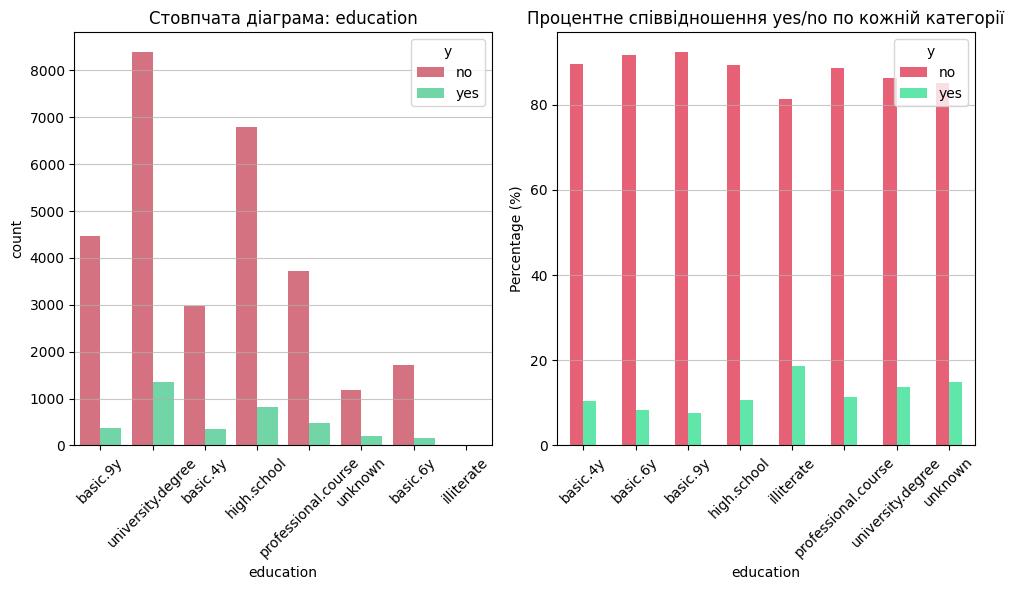

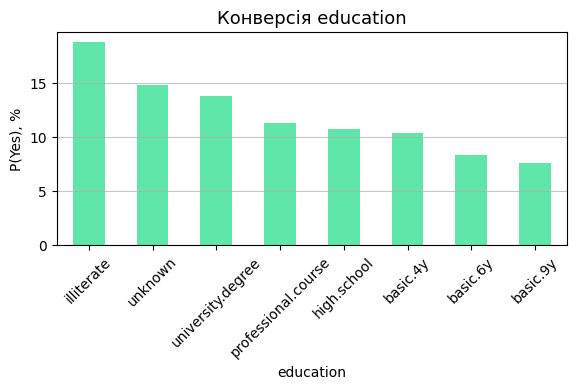

In [20]:
eda_category(train_df, 'education', target_cat_col)

* Колонка 'education' містить 32950 спостережень та 8 унікальних категорій, пропущені значення відсутні.
* Категорії даної ознаки незбалансовані:
  - 2 категорії ('university.degree' та 'high.school') разом становлять 52,5% усіх спостережень
  - категорія 'illiterate' становить лише 0,05%
* Візуалізація даних показує:
   - частка негативної відповіді в кожній категорії становить понад 80%, водночас частка позитивних відповідей дещо відрізняється в залежності від рівня освіти
   - клієнти з вищою освітою дещо частіше дають позитивну відповідь
   - категорії 'illiterate' та unknown мають найвищі частки серед позитивних відповідей, але їх вибірки дуже мала (0,05% та 4,24% відповідно), тому дані можуть бути нестабільними

**Гіпотеза:** рівень освіти клієнта може бути пов'язаний з готовністю відкрити депозит, тому ознака 'education' може бути інформативною для моделі.

### Аналіз змінної 'default'
– чи є у клієнта прострочений кредит

==================== Column: default ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 3
Кількість пропущених значень: 0


default,no,unknown,yes
value_counts,26007.00,6940.00,3.00
value_percentage,78.93,21.06,0.01


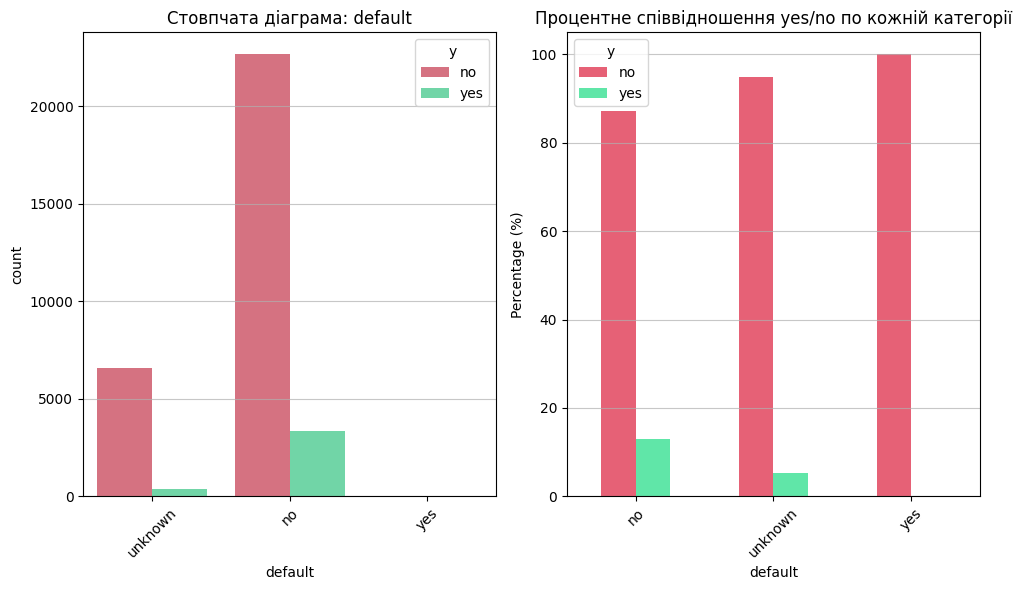

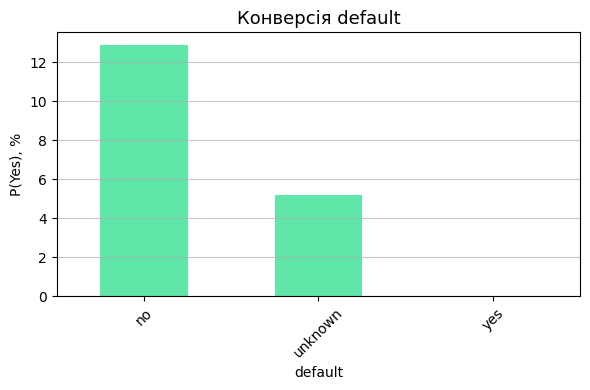

In [21]:
eda_category(train_df, 'default', target_cat_col)

* Колонка 'default' містить 32950 спостережень та 3 унікальних категорії, пропущені значення відсутні.
* Категорії даної ознаки незбалансовані:
  - клієнти без прострочених кредитів становлять ~79% від усіх спостережень
  - клієнти з простроченими кредитами - лише 0,01%, що може не нести корисної інформації для моделі
* Візуалізація даних показує:
   - категорія 'no' має найвищу конверсію (~13%)
   - категорія 'unknown' має конверсію ~5%
   - категорія 'yes' - конверсія нульова, але це може бути результатом дуже малої кількості даних (лише 3 випадки)
  
**Гіпотеза:** ознака 'default' має певний зв'язок з цільовою змінною (різні конверсії для 'no' і 'unknown'), але може мати обмежений вплив на модель, оскільки категорія 'yes' є надто рідкісною, що робить оцінку ненадійною.

### Аналіз змінної 'housing'
– чи має клієнт іпотечний кредит

==================== Column: housing ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 3
Кількість пропущених значень: 0


housing,yes,no,unknown
value_counts,17254.00,14900.00,796.00
value_percentage,52.36,45.22,2.42


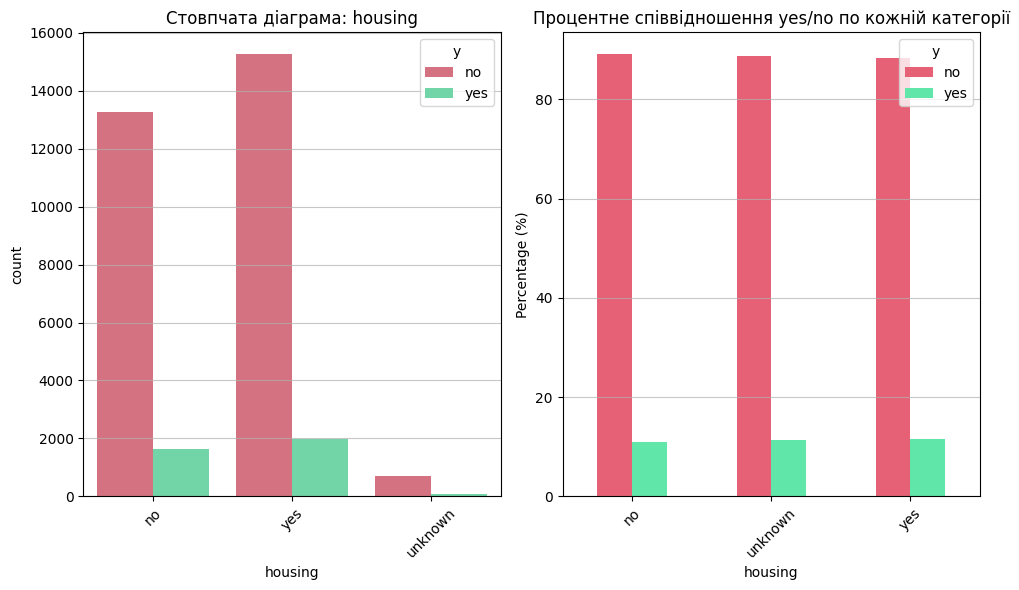

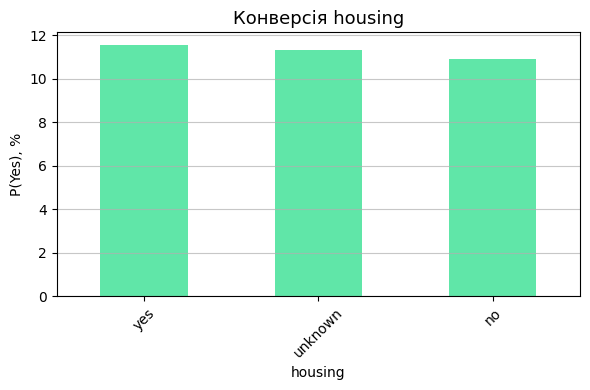

In [22]:
eda_category(train_df, 'housing', target_cat_col)

* Колонка 'housing' містить 32950 спостережень та 3 унікальних категорії, пропущені значення відсутні.
* Основні категорії даної ознаки ('yes' та 'no') збалансовані між собою: ~52% та ~45% відповідно
* Візуалізація даних показує:
   - конверсія для таргету майже однакова у всіх категоріях (~11%), що може свідчити про слабкий зв'язок між наявністю іпотечного кредиту та позитивною відповіддю на пропозицію оформити депозит
  
**Гіпотеза:** ознака 'housing' може мати обмежений вплив на модель, оскільки конверсія для різних категорій мало відрізняється.

### Аналіз змінної 'loan'
– чи має клієнт споживчий кредит

==================== Column: loan ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 3
Кількість пропущених значень: 0


loan,no,yes,unknown
value_counts,27131.00,5023.00,796.00
value_percentage,82.34,15.24,2.42


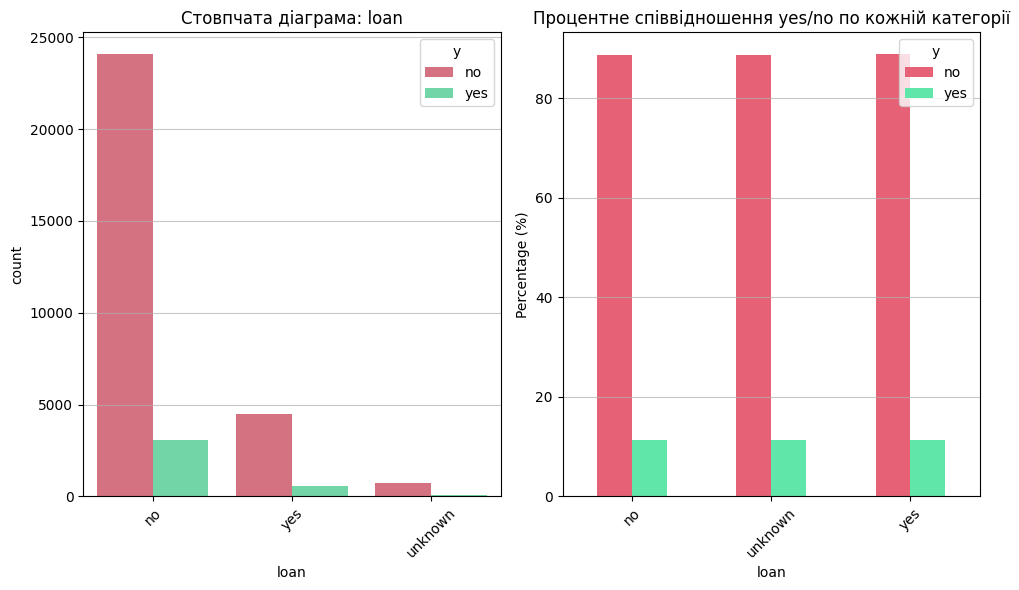

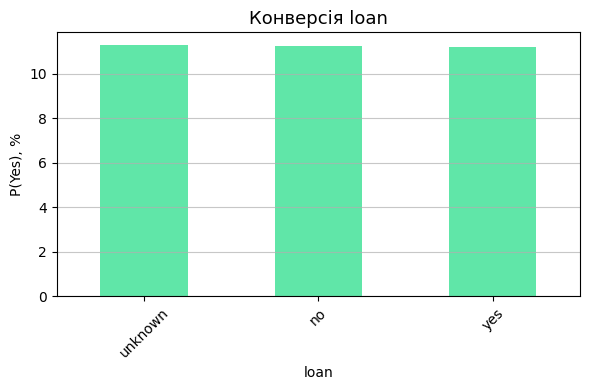

In [23]:
eda_category(train_df, 'loan', target_cat_col)


* Колонка 'loan' містить 32950 спостережень та 3 унікальних категорії, пропущені значення відсутні.
* Категорії даної ознаки не збалансовані між собою: 'no' - ~52%, 'yes' - ~15%, 'unknown' - ~2%
* Візуалізація даних показує:
   - конверсія для таргету майже однакова у всіх категоріях (~11%), що може свідчити про слабкий зв'язок між наявністю споживчого кредиту та позитивною відповіддю на пропозицію оформити депозит
  
**Гіпотеза:** ознака 'loan' може мати обмежений вплив на модель, оскільки конверсія для різних категорій мало відрізняється.

**Гіпотеза для блоку "Загальні дані про клієнта":**
- найсильнішими предикторами можуть стати ознаки job та education (вони мають більш суттєві різниці конверсій між своїми категоріями)
- інші ознаки можуть нести додаткову інформацію для моделі
- є рідкісні категорії, що можуть бути статистичним шуном і призвести до ненадійної оцінки.

Окремі групи клієнтів (student, retired, single, higher education) демонструють вищу конверсію, але їхній вплив слід розглядати разом з іншими ознаками.

## АНАЛІЗ ДАНИХ ПРО ОСТАННІЙ КОНТАКТ У МЕЖАХ ПОТОЧНОЇ КАМПАНІЇ

### Аналіз змінної 'contact'
– тип зв’язку при останньому контакті

==================== Column: contact ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 2
Кількість пропущених значень: 0


contact,cellular,telephone
value_counts,20908.00,12042.00
value_percentage,63.45,36.55


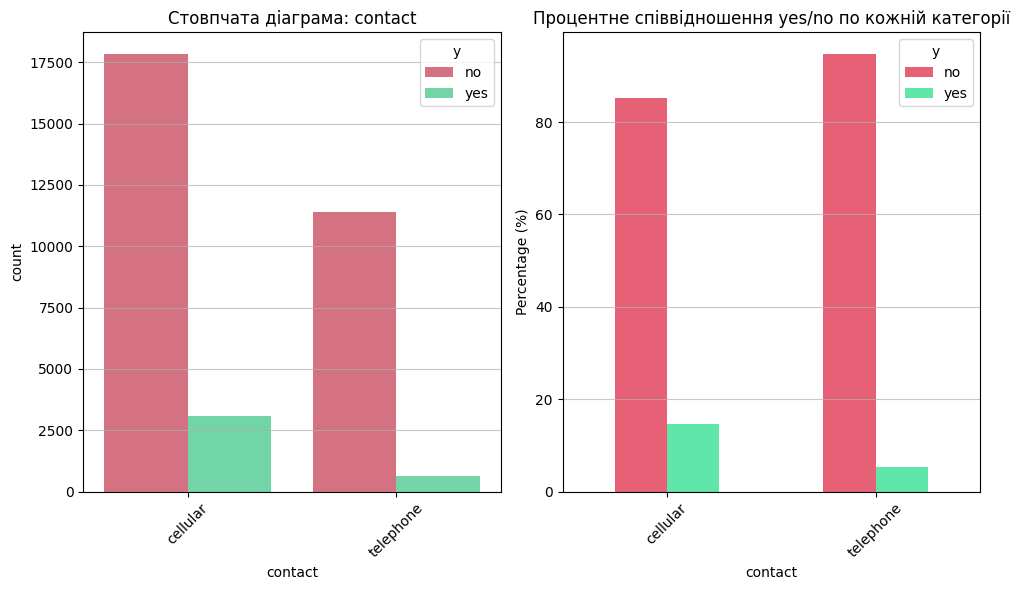

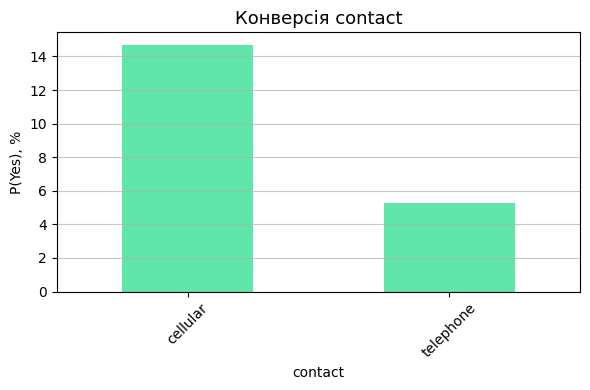

In [24]:
eda_category(train_df, 'contact', target_cat_col)

* Колонка 'contact' містить 32950 спостережень та 2 унікальних категорії, пропущені значення відсутні.
* Категорії даної ознаки не збалансовані між собою: 'cellular' - ~63%, 'telephone' - ~37% спостережень
* Візуалізація даних показує значну різницю між конверсіями для категорій:
  - 'cellular' - ~14%
  - 'telephone' - ~5%,
   
 що свідчить про сильний зв'язок між типом зв'язку та позитивною відповіддю на пропозицію оформити депозит
  
**Гіпотеза:** ознака 'contact' ймовірно є сильним предиктором для цільової змінної.

### Аналіз змінної 'month'
– місяць останнього контакту

==================== Column: month ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 10
Кількість пропущених значень: 0


month,may,jul,aug,jun,nov,apr,oct,sep,mar,dec
value_counts,11011.00,5763.00,4948.00,4247.00,3266.00,2085.00,587.00,464.00,436.00,143.00
value_percentage,33.42,17.49,15.02,12.89,9.91,6.33,1.78,1.41,1.32,0.43


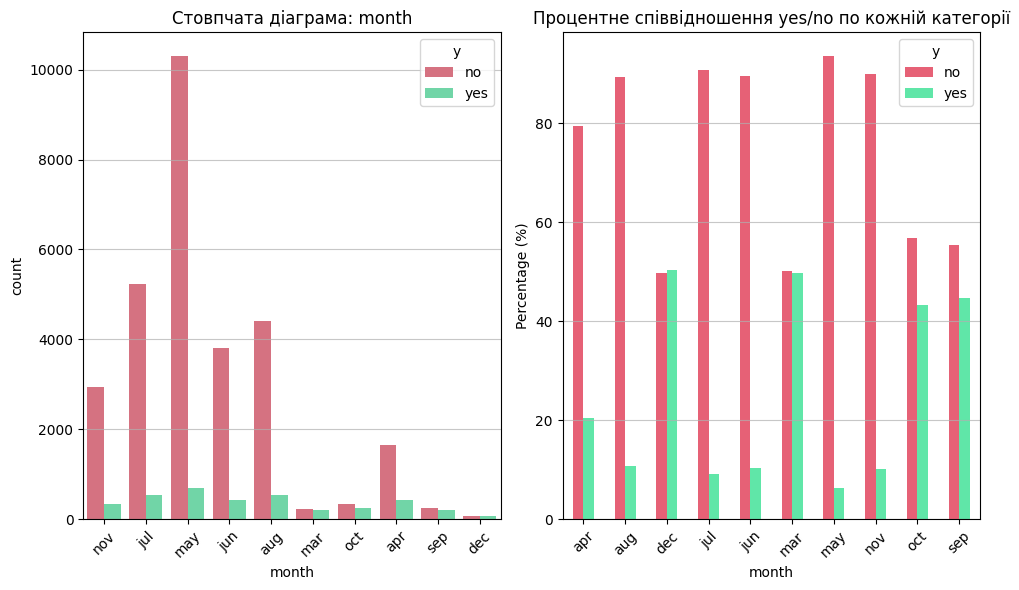

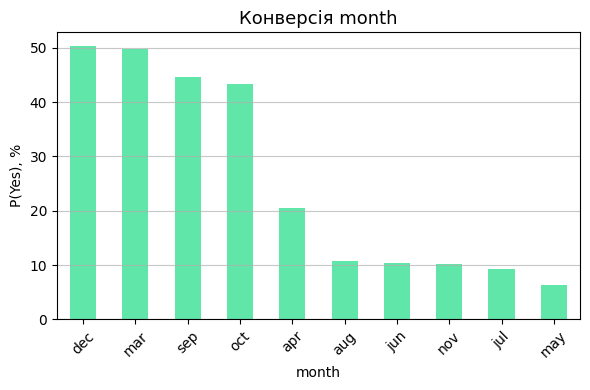

In [25]:
eda_category(train_df, 'month', target_cat_col)

* Колонка 'month' містить 32950 спостережень та 10 унікальних категорій, пропущені значення відсутні.
* Категорії даної ознаки незбалансовані
* В даних відсутні 2 місяці: січень та лютий
* Візуалізація даних показує:
  - обернений зв'язок між кількістю дзвінків та конверсією
  - найвища конверсія у грудні і березні (~50%)
  - найнижча конверсія у липні та травні (менше 10%),

 що може описувати не сезонність поведінки клієнтів, а періоди банківських кампаній та їх активність
  
**Гіпотеза:** ознака 'month' може відображати активність маркетингових кампаній, а не сезонність прийнятих клієнтами рішень щодо відкриття депозитів.

### Аналіз ознаки 'day_of_week'
– день тижня останнього контакту

==================== Column: day_of_week ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 5
Кількість пропущених значень: 0


day_of_week,thu,mon,wed,tue,fri
value_counts,6857.00,6812.00,6515.00,6444.00,6322.00
value_percentage,20.81,20.67,19.77,19.56,19.19


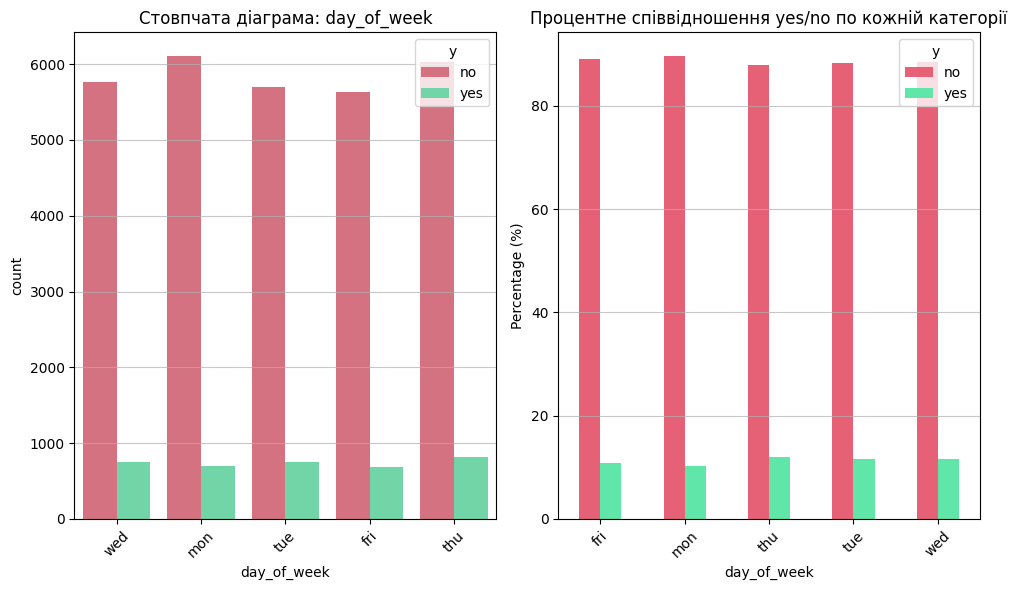

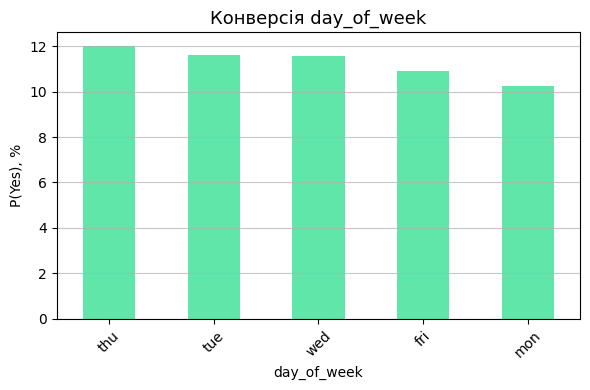

In [26]:
eda_category(train_df, 'day_of_week', target_cat_col)

* Колонка 'day_of_week' містить 32950 спостережень та 5 унікальних категорій, пропущені значення відсутні.
* Розподіл дзвінків збалансований: кожен день тижня має частку від ~19% до ~21%
* В даних відсутні 2 дні: субота та неділя - ймовірно, у вихідні кампанії не проводились
* Візуалізація даних показує:
  - конверсія для кожного дня тижня коливається в межах 10-12%

**Гіпотеза:** ознака 'day_of_week' може бути слабким предиктором для цільової змінної.

### Аналіз змінної 'duration'

– тривалість останнього контакту в секундах

==================== Column: duration ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 1467
Кількість пропущених значень: 0
Асиметрія даних: 3.33
Викиди: 2366
Медіана "no": 164.0
Медіана "yes": 448.0
count    32950.00
mean       258.13
std        258.98
min          0.00
25%        103.00
50%        180.00
75%        319.00
max       4918.00
Name: duration, dtype: float64


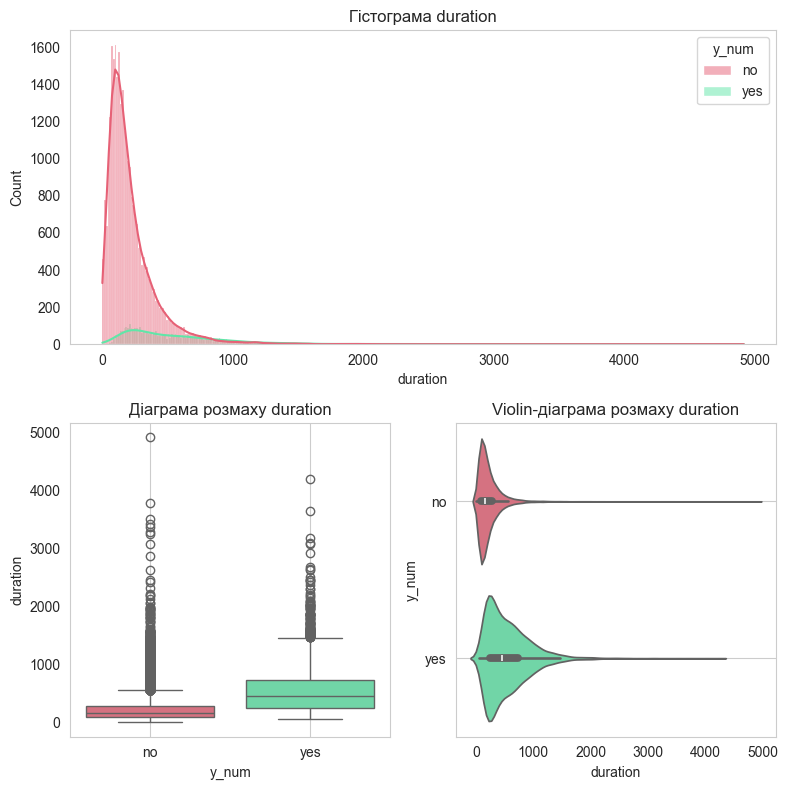

In [19]:
eda_numeric(train_df, 'duration', target_col)

* Колонка 'duration' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 0 до 4918 секунд, що виглядає реалістично.
* Половина розмов триває до 180 секунд (3 хвилини), середня тривалість 258 секунд (майже 4,5 хвилини), але є і дуже довгі розмови - до 82 хвилин.
* Візуалізація даних показує:
  - сильна асиметрія, розподіл правоскошений (асиметрія 3,33)
  - медіана 'yes' значно більша за медіану 'no' (448 проти 164), отже чим довша тривалість розмови, тим більша ймовірність 'yes'

**Гіпотеза:** оскільки значення 'duration' не відоме до кінця розмови і при цьому має сильний зв'язок з цільовою змінною, цю колонку варто прибрати з даних перед навчанням моделі, щоб уникнути витоку даних.

**Гіпотеза для блоку "Дані про контакт у межах поточної кампанії":**
- найсильнішим предиктором може стати ознака contact (суттєва різниця конверсій між категоріями)
- ймовірно дуже слабкий предиктор - day_of_week, але він може доповнювати загальну інформацію
- інші ознаки можуть нести додаткову інформацію для моделі
- duration слід виключити з моделі, щоб запобігти витоку даних

Слід звернути увагу, що ознаки цього блоку характеризують не стільки поведінкові патерни клієнтів, скільки самі маркетингові кампанії банківської установи.


## АНАЛІЗ ІНШИХ АТРИБУТІВ

### Аналіз змінної 'campaign'
-кількість контактів у межах поточної кампанії для цього клієнта (включає останній контакт).

==================== Column: campaign ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 40
Кількість пропущених значень: 0
Асиметрія даних: 4.74
Викиди: 1916
Медіана "no": 2.0
Медіана "yes": 2.0
count    32950.00
mean         2.56
std          2.75
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64


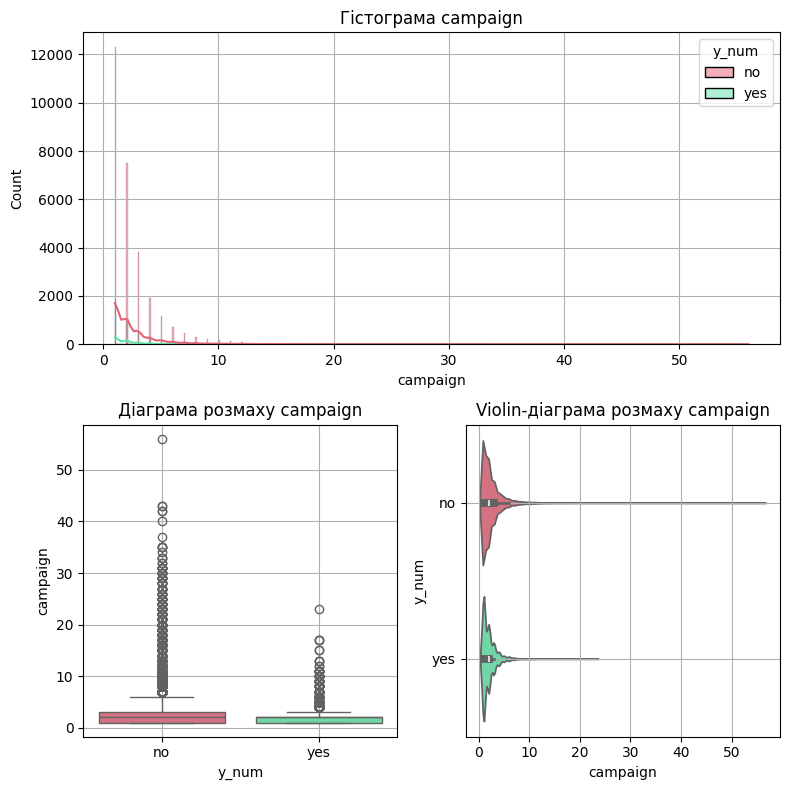

In [28]:
eda_numeric(train_df, 'campaign', target_col)

* Колонка 'campaign' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 1 до 56 контактів, що виглядає реалістично.
* Більшість клієнтів (75% і більше) мали до трьох контактів в межах поточної кампанії.
* Візуалізація даних показує:
  - сильна асиметрія, розподіл правоскошений (асиметрія 4.74)
  - викиди в групі 'yes' значно менші
  - медіана 'yes' і медіана 'no' рівні

**Гіпотеза:** коли кількість контактів стає більшою за ~10, ймовірність відповіді 'yes' зменшується. Колонку варто залишити для навчання моделі, оскільки вона може мати вплив на цільову змінну, особливо при великих значеннях campaign.

### Аналіз змінної 'pdays'
– кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (значення 999 означає, що клієнт раніше не контактувався).

Оскільки колонка 'pdays' містить дані із значенням 999, що є міткою відсутності контактів, має сенс зробити окремий попередній аналіз тільки для клієнтів, що мали контакт із банком.


In [29]:
# частка значень у колонці 'pdays'
(train_df.pdays.value_counts(normalize=True) * 100).to_frame().T

pdays,999,3,6,4,2,7,9,10,5,12,...,16,17,18,22,21,19,25,20,27,26
proportion,96.279211,1.07739,1.022762,0.294385,0.157815,0.14264,0.136571,0.130501,0.121396,0.121396,...,0.027314,0.024279,0.018209,0.009105,0.00607,0.00607,0.003035,0.003035,0.003035,0.003035


==================== Column: pdays ====================
Загальна кількість значень: 1226
Кількість унікальних значень: 26
Кількість пропущених значень: 0
Асиметрія даних: 1.55
Викиди: 73
Медіана "no": 6.0
Медіана "yes": 6.0
count    1226.00
mean        6.00
std         3.89
min         0.00
25%         3.00
50%         6.00
75%         7.00
max        27.00
Name: pdays, dtype: float64


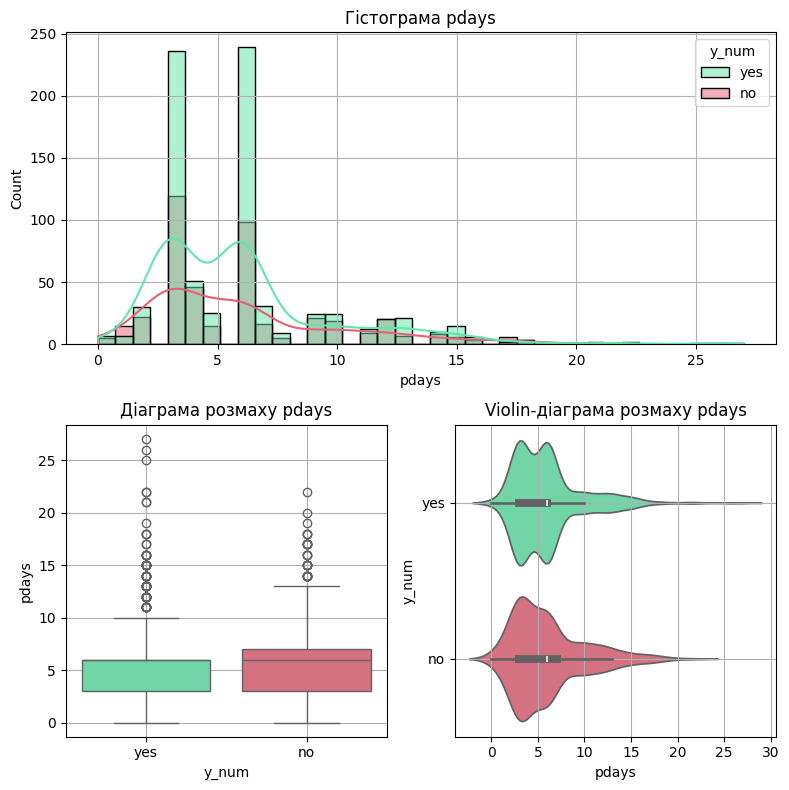

In [30]:
# аналіз даних з реальними контактами (без 999)
eda_numeric(train_df[train_df.pdays != 999], 'pdays', target_col)

* Колонка 'pdays' містить числові значення, пропущені значення відсутні.
* Діапазон значень (окрім значення 999, що є міткою відсутності контактів) від 0 до 27 днів , що виглядає реалістично.
* 50% контактів відбулися 6 і менше днів тому, 75% - 7 днів тому або менше.
* Частка клієнтів, що не мали контактів з банком в межах попередньої кампанії, становить 96%.
* Клієнти, що мали контакти з банком в межах попередньої кампанії:
  - частка становить ~4% від загальної кількості
  - правоскошений розподіл (асиметрія 1,55), але медіанне значення для груп 'yes' та 'no' однакове (=6), графіки розподілів схожі.

**Гіпотеза:** числові значення ознаки 'pdays' доступні лише для невеликої частини клієнтів (менше 4%) і навряд чи можуть бути сильним предиктором у своєму початковому вигляді. Водночас сам факт наявності або відсутності попереднього контакту може бути інформативною ознакою, тому варто розглядати її як бінарну змінну або в комбінації з іншими ознаками.

### Аналіз змінної 'previous'
– кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).

In [31]:
(train_df.previous.value_counts(normalize=True) * 100).to_frame().T

previous,0,1,2,3,4,5,6,7
proportion,86.239757,11.147193,1.83915,0.531108,0.182094,0.042489,0.015175,0.003035


==================== Column: previous ====================
Загальна кількість значень: 4534
Кількість унікальних значень: 7
Кількість пропущених значень: 0
Асиметрія даних: 3.04
Викиди: 861
Медіана "no": 1.0
Медіана "yes": 1.0
count    4534.00
mean        1.27
std         0.65
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         7.00
Name: previous, dtype: float64


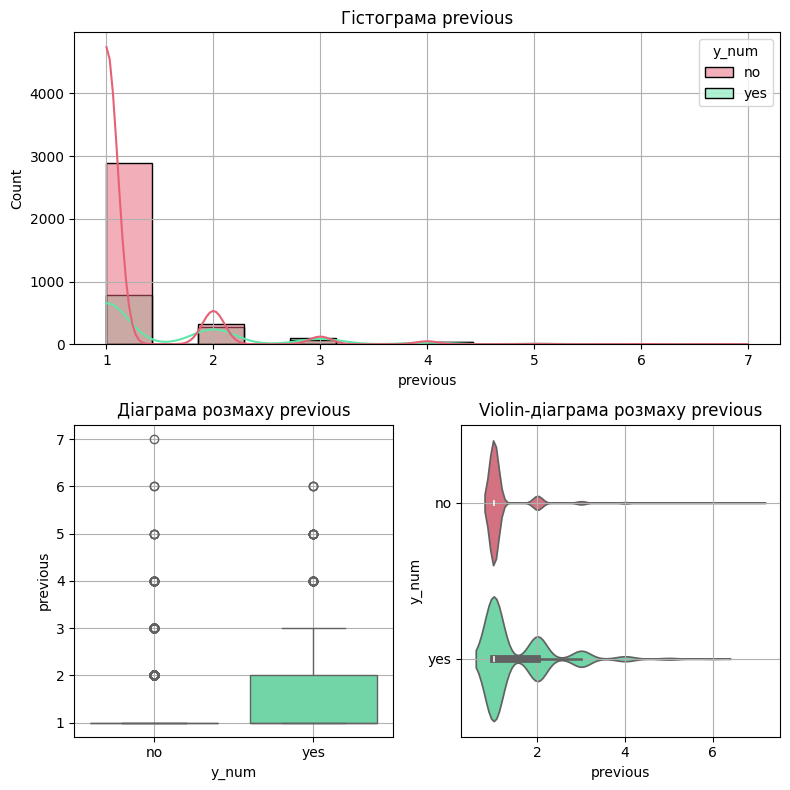

In [32]:
eda_numeric(train_df[train_df.previous != 0], 'previous', target_col)

* Колонка 'previous' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 0 до 7 контактів, що виглядає реалістично.
* Частка клієнтів, що не мали контактів з банком до поточної кампанії, становить 86%.
* Клієнти, що мали контакти з банком до поточної кампанії:
  - частка становить ~14% від загальної кількості
  - правоскошений розподіл (асиметрія 3.04), але медіанне значення для груп 'yes' та 'no' однакове (=1), графіки розподілів схожі.
  
**Гіпотеза:** дані про кількість контактів до поточної кампанії доступні лише для 14% клієнтів. Як і у випадку ознаки 'pdays', є сенс розглядати ці дані як бінарну ознаку (наявність або відсутність попередніх контактів) або розглянути в комбінації з іншими ознаками.

### Аналіз ознаки 'poutcome'
– результат попередньої маркетингової кампанії


==================== Column: poutcome ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 3
Кількість пропущених значень: 0


poutcome,nonexistent,failure,success
value_counts,28416.00,3429.00,1105.00
value_percentage,86.24,10.41,3.35


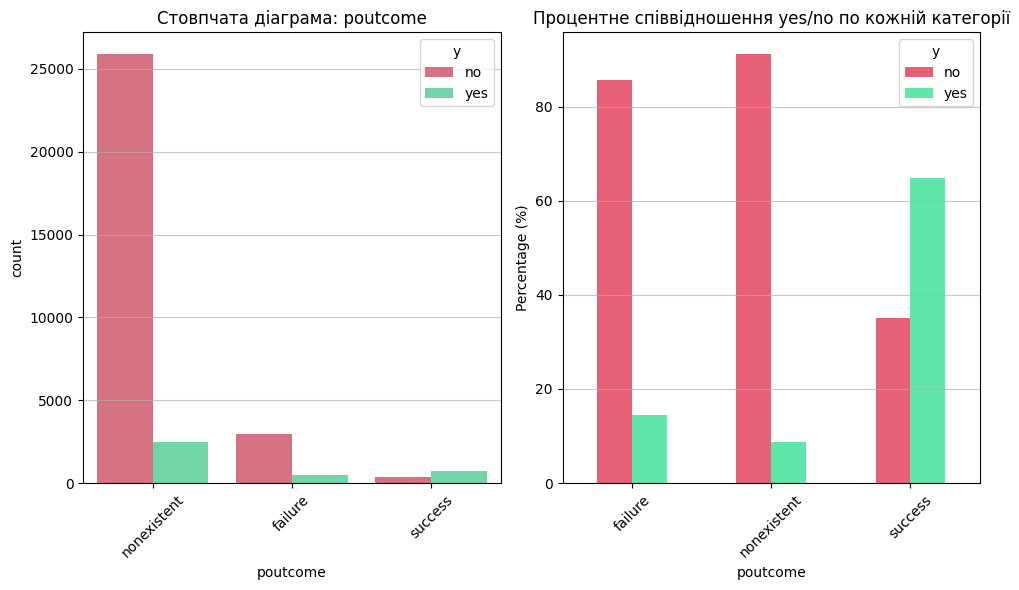

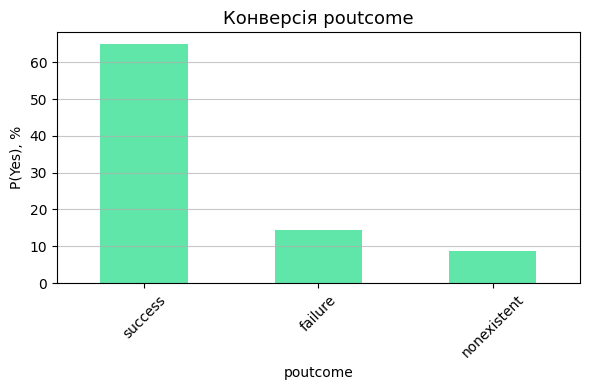

In [33]:
eda_category(train_df, 'poutcome', target_cat_col)

* Колонка 'poutcome' містить 32950 спостережень та 3 унікальних категорії, пропущені значення відсутні.
* Категорії даної ознаки не збалансовані:
  - 'nonexistent'	- ~86% всіх спостережень
  - 'failure' - 10% всіх спостережень
  - 'success' - 3% всіх спостережень
* Візуалізація даних показує значну різницю між конверсіями для категорій:
  - 'nonexistent' - ~10%
  - 'failure' - ~15%
  - 'success' - ~65%
  
**Гіпотеза:** ознака 'poutcome' ймовірно є суттєвим предиктором для цільової змінної, оскільки спостерігається доволі сильний зв'язок між результатом попередньої кампанії та рішенням відкрити депозит.

**Гіпотеза для блоку "Інші атрибути":**
- найсильнішим предиктором може стати ознака poutcome (суттєва різниця конверсій між категоріями)
- ознаки 'pdays' та 'previous' ймовірно варто розглянути як бінарні
- не слід забувати про доволі суттєве зменшення конверсії при кількості контактів ('campaign') більше 10

## АНАЛІЗ АТРИБУТІВ СОЦІАЛЬНО-ЕКОНОМІЧНОГО КОНТЕКСТУ

### Аналіз 'emp.var.rate'
– темп зміни зайнятості (щоквартальний показник, числова змінна)

==================== Column: emp.var.rate ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 10
Кількість пропущених значень: 0
Асиметрія даних: -0.72
Викиди: 0
Медіана "no": 1.1
Медіана "yes": -1.8
count    32950.00
mean         0.08
std          1.57
min         -3.40
25%         -1.80
50%          1.10
75%          1.40
max          1.40
Name: emp.var.rate, dtype: float64


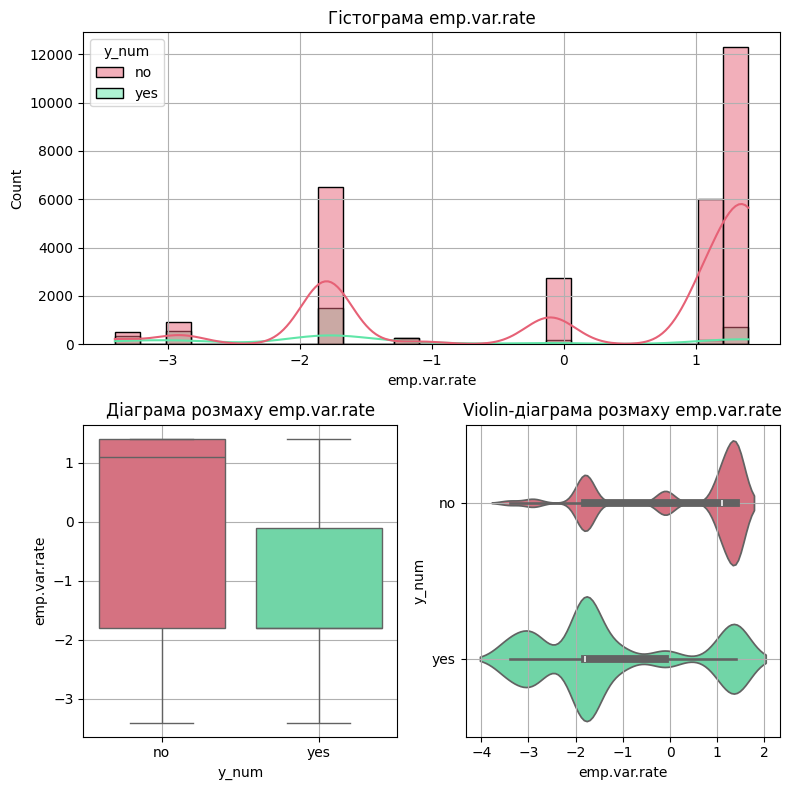

In [34]:
eda_numeric(train_df, 'emp.var.rate', target_col)

In [35]:
(train_df['emp.var.rate'].value_counts(normalize=True) * 100).to_frame().T

emp.var.rate,1.4,-1.8,1.1,-0.1,-2.9,-3.4,-1.7,-1.1,-3.0,-0.2
proportion,39.465857,22.327769,18.740516,8.925645,4.024279,2.60091,1.905918,1.575114,0.415781,0.018209


* Колонка 'emp.var.rate' містить числові значення, пропущені значення відсутні.
* Діапазон значень від -3.4 до 1.4 років, що цілком реалістично.
* Візуалізація даних показує:
   - піки в значеннях (їх всього 10), що може говорити про категоріальність змінної 'emp.var.rate', хоч вона і є числовою
   - лівоскошений розподіл (асиметрія -0,72)
   - розподіли для груп 'yes' та 'no' помітно відрізняються, медіана для 'yes' значно нижча за медіану для 'no': -1,8 та 1,1 відповідно.

**Гіпотеза:** ознака 'emp.var.rate' може стати сильним предиктором для цільової змінної, оскільки різні темпи зміни зайнятості можуть впливати на ймовірність позитивної відповіді.

### Аналіз змінної 'cons.price.idx'
– індекс споживчих цін (щомісячний показник, числова змінна)

==================== Column: cons.price.idx ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 26
Кількість пропущених значень: 0
Асиметрія даних: -0.23
Викиди: 0
Медіана "no": 93.918
Медіана "yes": 93.2
count    32950.00
mean        93.58
std          0.58
min         92.20
25%         93.08
50%         93.75
75%         93.99
max         94.77
Name: cons.price.idx, dtype: float64


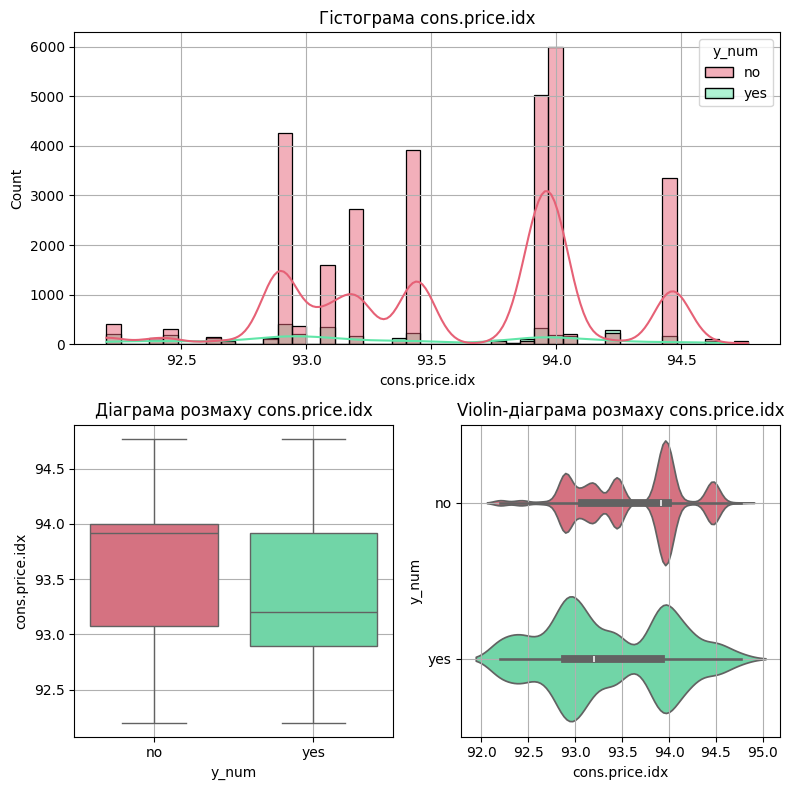

In [36]:
eda_numeric(train_df, 'cons.price.idx', target_col)

* Колонка 'cons.price.idx' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 92,20 до 94,77, що цілком реалістично.
* Візуалізація даних показує:
   - піки в значеннях (всього 26), що може говорити про категоріальність змінної 'cons.price.idx', хоч вона і є числовою
   - незначна ліва асиметрія (-0,23)
   - розподіли для груп 'yes' та 'no' помітно відрізняються, в поточному діапазоні значень медіана для 'yes' помітно нижча за медіану для 'no': 93,2 та 93,9 відповідно.

**Гіпотеза:** ознака 'cons.price.idx', як і 'emp.var.rate', є макроекономічним показником та може бути корисним предиктором для цільової змінної, оскільки зміни індексу споживчих цін, як і інші економічні умови,  можуть впливати на ймовірність позитивної відповіді.

### Аналіз змінної 'cons.conf.idx'
 – індекс довіри споживачів (щомісячний показник, числова змінна)

==================== Column: cons.conf.idx ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 26
Кількість пропущених значень: 0
Асиметрія даних: 0.31
Викиди: 359
Медіана "no": -41.8
Медіана "yes": -40.4
count    32950.00
mean       -40.51
std          4.63
min        -50.80
25%        -42.70
50%        -41.80
75%        -36.40
max        -26.90
Name: cons.conf.idx, dtype: float64


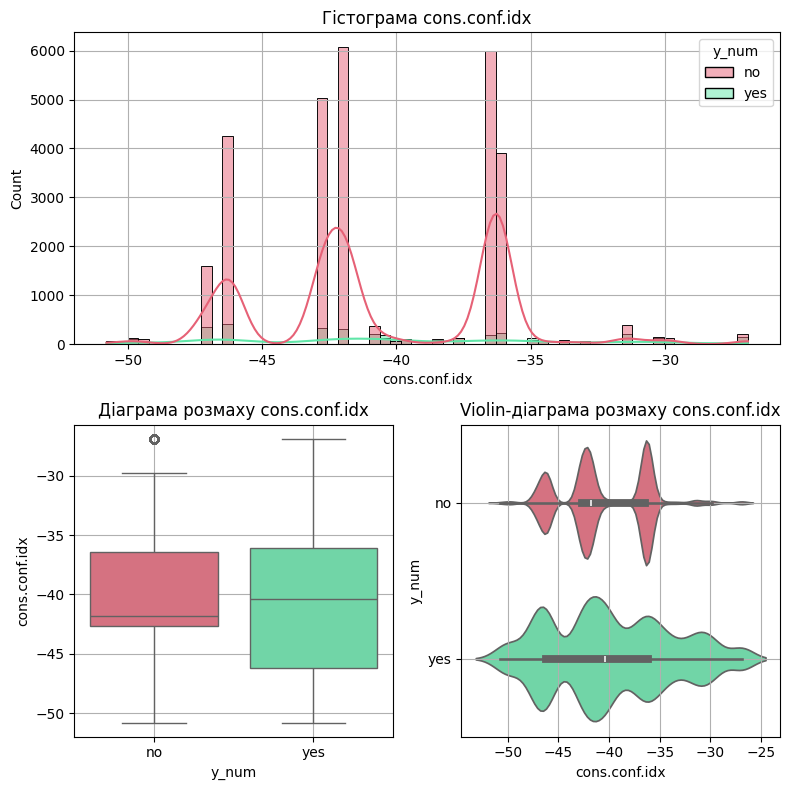

In [37]:
eda_numeric(train_df, 'cons.conf.idx', target_col)

* Колонка 'cons.conf.idx' містить числові значення, пропущені значення відсутні.
* Діапазон значень від -50,8 до -26,90, що цілком реалістично.
* Візуалізація даних показує:
   - піки в значеннях (всього 26 унікальних значень), що може говорити про категоріальність змінної 'cons.conf.idx', хоч вона і є числовою
   - незначна права асиметрія (0,31)
   - розподіли для груп 'yes' та 'no' відрізняються, що видно на  діаграмах розмаху, хоча різниця між медіанами відносно невелика: -40.4 для 'yes' і -41.8 для 'no'.

**Гіпотеза:** ознака cons.conf.idx є макроекономічним показником і може впливати на ймовірність позитивної відповіді клієнта.

### Аналіз змінної 'euribor3m'
– ставка Euribor на 3 місяці (щоденний показник, числова змінна)

==================== Column: euribor3m ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 312
Кількість пропущених значень: 0
Асиметрія даних: -0.71
Викиди: 0
Медіана "no": 4.857
Медіана "yes": 1.266
count    32950.00
mean         3.62
std          1.74
min          0.63
25%          1.34
50%          4.86
75%          4.96
max          5.04
Name: euribor3m, dtype: float64


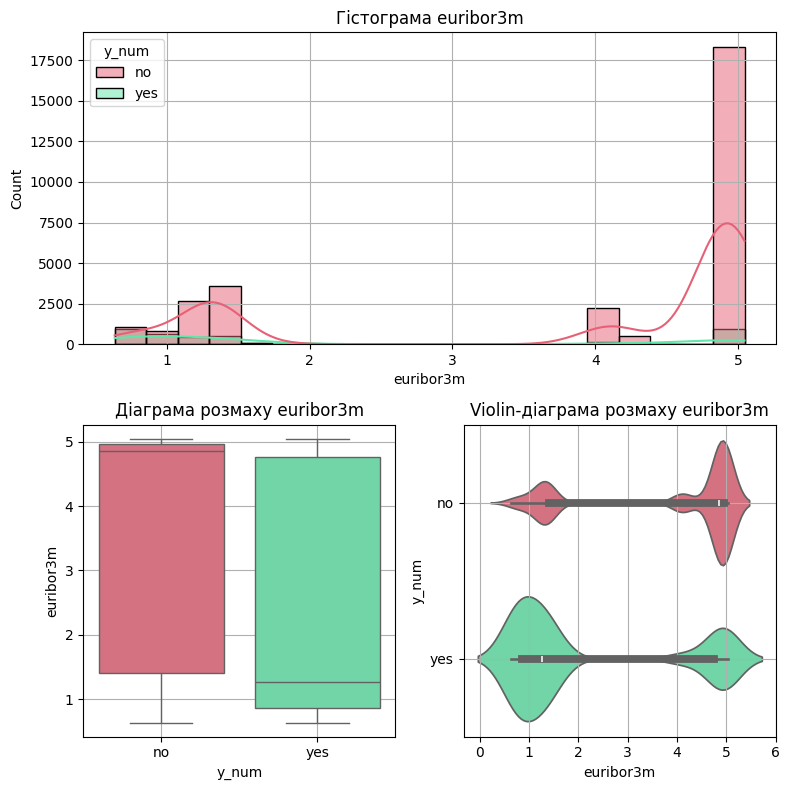

In [38]:
eda_numeric(train_df, 'euribor3m', target_col)

* Колонка 'euribor3m' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 0,63 до 5,04, що цілком реалістично.
* Візуалізація даних показує:
   - помірна ліва асиметрія (0,71)
   - розподіли для груп 'yes' та 'no' суттєво відрізняються: медіана для 'no' (4.857) знаходиться близько до верхньої межі розподілу, а медіана для 'yes' (1.266) значно ближча до нижньої межі
   - на violin-діаграмі помітна висока щільність значень на протилежних кінцях розподілу для різних класів: коли ставка низька, щільність класу 'yes' значно вища і навпаки - при високій ставці переважає клас 'no'

**Гіпотеза:** ознака euribor3m може бути сильним предиктором для цільової змінної.

### Аналіз змінної 'nr.employed'
– кількість працевлаштованих осіб (щоквартальний показник, числова змінна)

==================== Column: nr.employed ====================
Загальна кількість значень: 32950
Кількість унікальних значень: 11
Кількість пропущених значень: 0
Асиметрія даних: -1.04
Викиди: 0
Медіана "no": 5195.8
Медіана "yes": 5099.1
count    32950.00
mean      5166.90
std         72.43
min       4963.60
25%       5099.10
50%       5191.00
75%       5228.10
max       5228.10
Name: nr.employed, dtype: float64


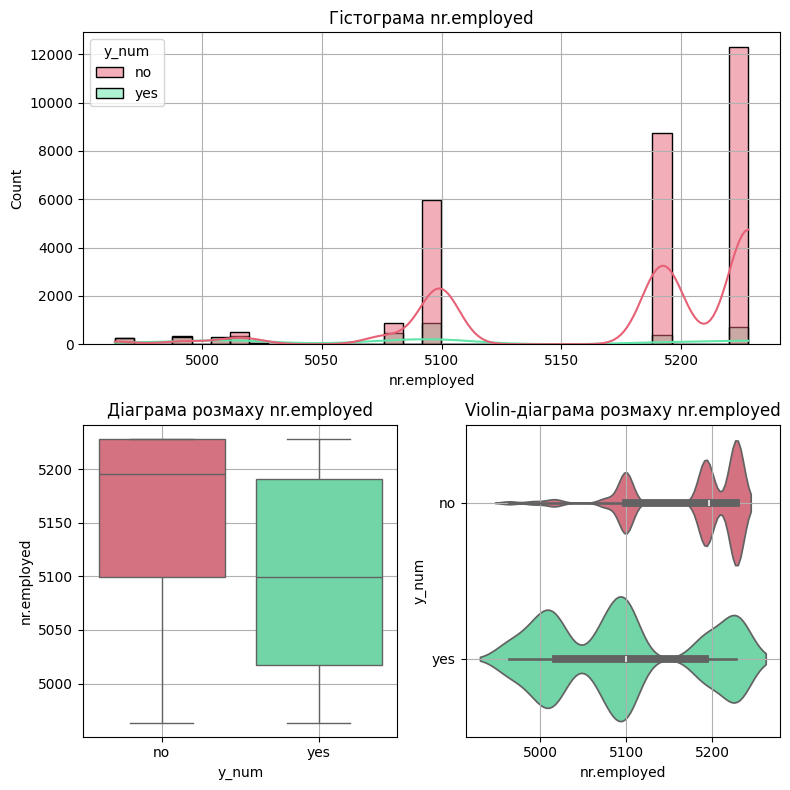

In [39]:
eda_numeric(train_df, 'nr.employed', target_col)

* Колонка 'nr.employed' містить числові значення, пропущені значення відсутні.
* Діапазон значень від 4963.60 до 5228.10 тис.осіб, що цілком реалістично.
* Візуалізація даних показує:
   - піки в значеннях (всього 11 унікальних значень), що робить змінну 'nr.employed' схожою на категоріальну, хоч вона є числовою
   - після значення ~5050 кількість відповідей 'no' помітно різко зростає
   - помірна ліва асиметрія (-1.04)
   - розподіли для груп 'yes' та 'no' відрізняються, що видно на  діаграмах розмаху
   - медіана класу 'yes' майже співпадає з нижньою межою першого квартилю класу 'no'.

**Гіпотеза:** ознака 'nr.employed' є макроекономічним показником і може суттєво впливати на ймовірність позитивної відповіді клієнта.
Також варто перевірити макроекономічні показники на кореляцію.

### Кореляційний аналіз між макроекономічними показниками (атрибутами соціально-економічного контексту)

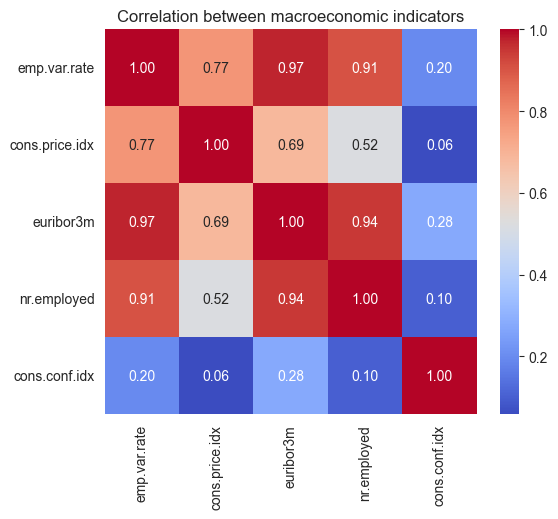

In [20]:
cols = [
    'emp.var.rate',
    'cons.price.idx',
    'euribor3m',
    'nr.employed',
    'cons.conf.idx'
]

plt.figure(figsize=(6, 5))
sns.heatmap(train_df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between macroeconomic indicators')
plt.show()

* Кореляційний аналіз показав сильну залежність (коефіцієнти кореляції перевищують 0.9) між наступними макроекономічними показниками: 'emp.var.rate', 'euribor3m' та 'nr.employed'. Ці змінні описують економічний стан, який може впливати на рішення клієнтів щодо відкриття депозиту: при зростанні цих показників ймовірність позитивної відповіді зменшується.

* Змінні 'cons.price.idx' та 'cons.conf.idx' мають помірну чи дуже слабку кореляцію з іншими економічними показниками і можуть дати моделі додаткову інформацію.
* Для Logistic Regression можна використати регуляризацію, щоб уникнути нестабільних коефіцієнтів, яка характерна для лінійних моделей при мультиколінеарності ознак.
* Нелінійні моделі (kNN, Decision Tree, алгоритми бустингу) менш чутливі до мультиколінеарності, тому всі ці ознаки можуть бути використані для навчання.


**Гіпотеза для блоку "Атрибути соціально-економічного контексту":**
- найсильнішими предикторами можуть стати ознаки emp.var.rate, euribor3m та nr.employed (вони мають більш суттєві різниці конверсій між своїми категоріями)
- cons.price.idx та cons.conf.idx — менш виражені, але можуть додати корисну інформацію
- обмежена кількість унікальних значень, що може призвести до ненадійної оцінки
- через сильну кореляцію між макропоказниками варто застосовувати регуляризацію для Logistic Regression, щоб уникнути нестабільних коефіцієнтів. У нелінійних моделях всі ознаки можна залишити.

## **Загальний висновок по EDA**

* Проведений аналіз показав, що ознаки в датасеті мають різну степінь інформативністі. Найбільш вагомими предикторами можуть стати ознаки, для яких спостерігається суттєва різниця у розподілах між цільовими класами:
  - пов’язані з попередніми контактами клієнта (poutcome, previous, pdays)
  - параметри поточної кампанії (contact, campaig)
  - макроекономічні показники (euribor3m, emp.var.rate, nr.employed)

* Деякі ознаки (housing, loan, day_of_week) демонструють слабкий зв’язок із цільовою змінною і, ймовірно, матимуть обмежений вплив на якість моделі.

* Ознака duration має сильний зв’язок із цільовою змінною, але є недоступною на момент прийняття рішення, тому її варто виключити з моделі для уникнення витоку даних.

* При викоритсанні лінійних моделей варто врахувати сильну кореляцію між макроекономічними показниками.

* Значна частина ознак відображає не індивідуальні характеристики клієнтів, а особливості маркетингової кампанії та економічний стан в певний період часу. Це може потребувати уважності в інтерпретації результатів навчання моделі.


# Опис обраних методів навчання та метрики оцінки якості

Даний датасет має наступні осбливості:
- незбалансований таргет: 'no' ~89% та 'yes' ~11%
- велика частка категоріальних ознак (50%)
- задача - бінарна класифікація

З урахуванням цих даних будуть використані наступні алгоритми:
* Logistic Regression - проста модель, добре інтерпретується
* Decision Tree - проста модель, працює з нелінійними залежностіми, легко інтерпретується та візуалізується, не потребує масштабування ознак
* kNN - простий алгоритм, зрозумілий, працює з нелінійними залежностіми
* Gradient Boosting - точний, працює з нелінійними залежностіми та з різними типами даних
* LightGBM - точний, швидкий

В якості метрики оцінки якості обрано:
- AUROC у якості основної метрики: підходить для датасетів з незбалансованими класами, не залежить від порогу класифікації, а оцінює здатність моделі розрізняти класи загалом
- f1-score у якості допоміжної метрики: цей показник є балансом між прецизійністю та повнотою, добре підходить для датасетів з незбалансованими класами і для порівняння різних моделей між собою, також, на відміну від AUROC, показує як модель працює при конкретному порозі класифікації

# Препроцесинг даних перед навчанням моделей

 Препроцесинг включає:
  - обробку категоріальних змінних:
    - OneHotEncoder для усіх моделей і OrdinalEncoder для LightGBM
  - групування категорій в категоріальних змінних буде використовуватись при створенні додаткових ознак
  - заповнення пропущених значень: в даному датасеті пропущених значень немає, але в пайплайні цей момент враховано
  - масштабування числових ознак із використанням RobustScaler, який є менш чутливим до викидів

Створення додаткових ознак буде розглянуто окремо, оскільки їх вплив може відрізнятися залежно від моделі.

# Тренування різних типів моделей машинного навчання

  - Logistic Regression
  - kNN
  - Decision Tree
  - XGBoost


In [12]:
# ініціалізація таблиць (проміжні таблиці результатів для кожної моделі окремо)
logreg_results = None
knn_results = None
dt_results = None
xgbm_results = None
lgbm_results = None

# головна таблиця результатів
main_results = None

## LogisticRegression

In [13]:
# формування даних
train_fe = train_df.copy()
val_fe = val_df.copy()

In [14]:
# Експерименти з Feature Engineering

train_fe['was_contacted'] = (train_fe['pdays'] != 999).astype(int)
val_fe['was_contacted'] = (val_fe['pdays'] != 999).astype(int)

# train_fe['was_contacted_x_previous'] = train_fe['was_contacted'] * train_fe['previous']
# val_fe['was_contacted_x_previous'] = val_fe['was_contacted'] * val_fe['previous']

# train_fe['many_contacts'] =(train_fe['campaign'] > 3).astype(int)
# val_fe['many_contacts'] = (val_fe['campaign'] > 3).astype(int)

# 2. + log features
# train_fe['age_x_campaign'] = train_fe['age'] * train_fe['campaign']
# val_fe['age_x_campaign'] = val_fe['age'] * val_fe['campaign']

train_fe['age_squared'] = train_fe['age'] ** 2
val_fe['age_squared'] = val_fe['age'] ** 2

# train_fe['education_clean'] = train_fe['education'].replace({'unknown':'other'})
# val_fe['education_clean'] = val_fe['education'].replace({'unknown':'other'})


drop_cols = ['duration', 'pdays']

In [15]:
input_cols_fe = [col for col in train_fe.columns if col not in ['y', 'y_num']]

In [16]:
X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_fe,
    val_df=val_fe,
    input_cols=input_cols_fe,
    target_col=target_col,
    drop_cols=drop_cols)


=== LogReg ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      7310
           1       0.36      0.65      0.47       928

    accuracy                           0.83      8238
   macro avg       0.66      0.75      0.68      8238
weighted avg       0.88      0.83      0.85      8238

Confusion matrix (validation):
[[6265 1045]
 [ 329  599]]
Train AUROC: 0.7954
Validation AUROC: 0.8016


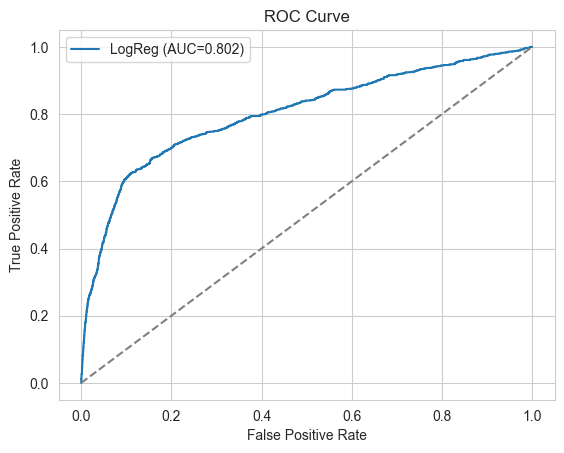

In [17]:
# Логістична регресія, навчання

log_reg = create_pipeline(
    model=LogisticRegression(
        max_iter=1000,
        C=1,
        class_weight='balanced'
        # solver='saga',
        # penalty='elasticnet',
        # l1_ratio=0.5,

    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=True,
    model_type='logistic'
)
log_reg.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = 'Пункт 17 + "education_clean"'

# оцінка результатів
logreg_results = evaluate_model('LogReg', log_reg,
                                X_train, y_train,
                                X_val, y_val,
                                log_reg.get_params(),
                                new_comment, logreg_results)

In [54]:
# збереження та вивід таблиці результатів logreg_results
save_results(logreg_results, '../outputs/logreg_results.csv')
logreg_results = pd.read_csv('../outputs/logreg_results.csv')
logreg_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7932,0.8011,0.3390,0.3382,max_iter=1000
1,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7950,0.8010,0.4516,0.4669,П.0 + class_weight='balanced'
2,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7874,0.7948,0.4209,0.4398,П.1 + C=0.001
3,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7929,0.7995,0.4396,0.4560,П.1 + C=0.01
4,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7947,0.8009,0.4495,0.4655,П.1 + C=0.1
5,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7950,0.8010,0.4516,0.4669,П.1 + C=1
6,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7951,0.8011,0.4521,0.4674,П.1 + C=5
7,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7951,0.8011,0.4519,0.4674,П.1 + C=10
8,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7951,0.8010,0.4518,0.4685,П.6 + liblinear + l1
9,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7951,0.8009,0.4518,0.4689,П.8 + 'was_contacted' - pdays


**Таблиця порівнянням якості моделі** з різними налаштуваннями, Feature Engineering тощо

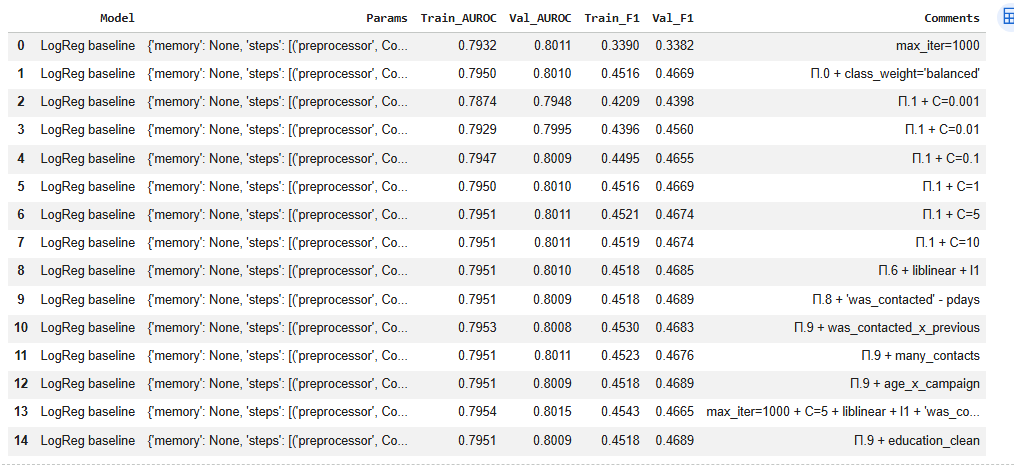

In [19]:
# підбір thresholds

y_val_proba = log_reg.predict_proba(X_val)[:, 1]

# перебір порогів класифікації
thresholds = [0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
thresholds_results = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)
    f1 = f1_score(y_val, y_pred)
    thresholds_results.append({
        'Model': 'LogReg baseline',
        'Params': log_reg.get_params(),
        'Threshold': t,
        'Val_F1': f1
    })

thresholds_res = pd.DataFrame(thresholds_results)
thresholds_res.to_csv('../outputs/thresholds_res.csv', header=False, index=False)
thresholds_res

,Model,Params,Threshold,Val_F1
0,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.1,0.202775
1,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.3,0.278700
2,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.4,0.396728
3,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.5,0.465785
4,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.6,0.500865
5,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7,0.501268
6,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8,0.456933
7,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.9,0.325926


**Таблиця результатів підбору порогу класифікації**

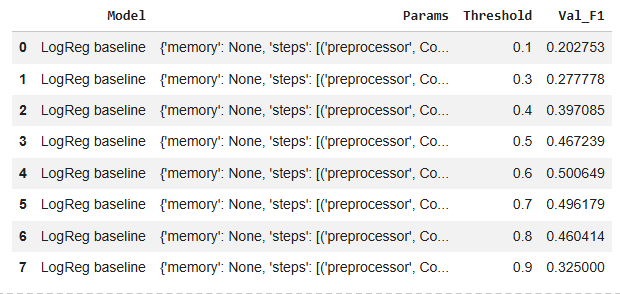

### **Висновки:**
* Модель логістичної регресії:
  - доволі добре розділяє класи: Val AUROC ~ 0.80
  - гірше виділяє позитивний клас без налаштування порогу:
      - f1_score ~ 0.47 при threshold = 0.5
      - f1_score ~ 0.50 при threshold = 0.6
* Найбільший вплив на якість моделі мають:
   - параметр class_weight='balanced'
   - підбір порогу класифікації threshold
* Feature Engineering (бінарні ознаки, очищення категоріальних змінних , взаємодія ознак тощо) не продемонстрував суттєвих змін
* Потенційні кроки щодо подальшої роботи:
   - видалення "шумних" категорій
   - створення поліноміальних ознак (але є ризик перенавчання через значну кількість one-hot-кодованих ознак)
   - групування рідкісних категорій
   - використання алгоритмів боротьби з дисбалансом класів (SMOTETomek, ADASYN тощо)

  Але оскільки модель вже показує доволі стабільну роботу, нові експеримнти можуть не дати суттєвого приросту якості.
* Дану модель надалі можна використовувати як базову, також вона є зручною для інтерпретації впливу ознак на цільову змінну.

  

## kNN

In [20]:
# формування даних
train_knn = train_df.copy()
val_knn = val_df.copy()

input_cols_knn = [col for col in train_knn.columns if col not in ['y', 'y_num']]
drop_cols = ['duration', ]

In [21]:
X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_knn,
    val_df=val_knn,
    input_cols=input_cols_knn,
    target_col=target_col,
    drop_cols=drop_cols)


In [22]:
knn_preprocessor = create_preprocessor(num_features, cat_features)

X_train_processed = knn_preprocessor.fit_transform(X_train)

X_val_processed = knn_preprocessor.transform(X_val)

param_grid = {'n_neighbors': np.arange(1, 20)}

grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=10,
    refit=True
)

grid.fit(X_train_processed, y_train)

# найкраща модель
knn_best = grid.best_estimator_

# найкращі параметри (k)
print('Найкращі параметри:', grid.best_params_)

Найкращі параметри: {'n_neighbors': np.int64(19)}



=== knn ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.66      0.21      0.31       928

    accuracy                           0.90      8238
   macro avg       0.79      0.60      0.63      8238
weighted avg       0.88      0.90      0.87      8238

Confusion matrix (validation):
[[7213   97]
 [ 737  191]]
Train AUROC: 0.8116
Validation AUROC: 0.7913


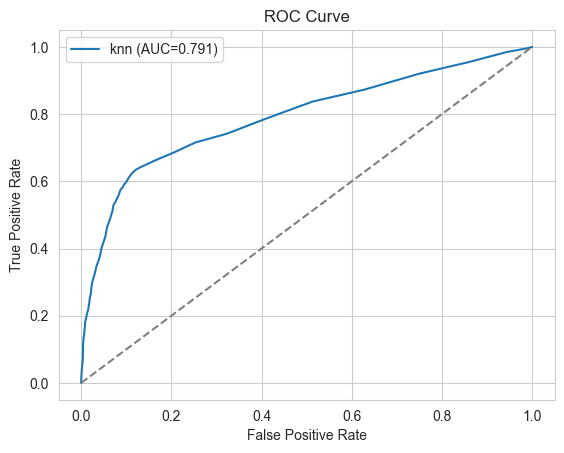

In [23]:
# модель
knn_model = create_pipeline(
    model=KNeighborsClassifier(
        n_neighbors=100,
        weights='uniform',  # 'distance' спрацював гірше
        metric='euclidean'
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='knn',
    scale_numeric=True
)

# навчання
knn_model.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = "n=100, weights='uniform', metric='euclidean'"

# оцінка результатів
knn_results = evaluate_model('knn', knn_model,
                             X_train, y_train,
                             X_val, y_val,
                             knn_model.get_params(),
                             new_comment, knn_results)

In [56]:
# збереження та вивід таблиці результатів knn_results
save_results(knn_results, '../outputs/knn_results.csv')
knn_results = pd.read_csv('../outputs/knn_results.csv')
knn_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9253,0.7485,0.4853,0.3963,"knn (n=5, weights='uniform')"
1,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.8899,0.7714,0.3834,0.3222,"knn (n=10, weights='uniform')"
2,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9999,0.7546,0.9793,0.3682,"knn (n=10, weights='distance')"
3,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9999,0.7581,0.9793,0.3625,"knn (n=19, weights='distance')"
4,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9999,0.7546,0.9793,0.3682,"knn (n=10, weights='distance', metric='euclide..."
5,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9999,0.7525,0.9792,0.3673,"knn (n=10, weights='distance', metric='manhatt..."
6,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.9999,0.7606,0.9792,0.3336,"knn (n=50, weights='distance', metric='euclide..."
7,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.8116,0.7912,0.3226,0.3141,"knn (n=100, weights='uniform', metric='euclide..."
8,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.8519,0.7801,0.3867,0.3490,"knn (n=100, weights='uniform', metric='euclide..."
9,kNN,"{'memory': None, 'steps': [('preprocessor', Co...",0.8116,0.7912,0.3226,0.3141,"n=100, weights='uniform', metric='euclidean'"


**Таблиця порівнянням якості моделі** з різними налаштуваннями

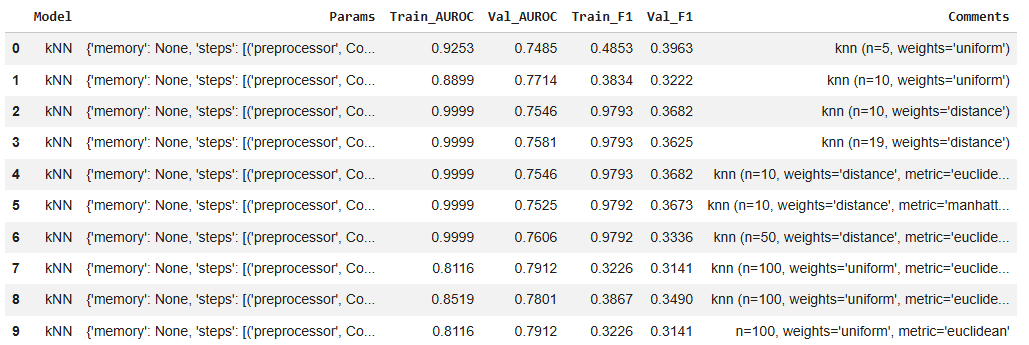

### **Висновки**

* Модель kNN:

  * досягла найкращих результатів (Val AUROC = 0.7912) при:
    - n_neighbors=100
    - weights='uniform'
    - metric='euclidean'
  * виявилась чутливою до гіперпараметрів та дисбалансу класів: збільшення n_neighbors призводить до зменшення перенавчання, але знижує f1-score

  * погано виявляє мінорний клас (f1-score при різних налаштуваннях коливається в межах 0.3141 - 0.3963)

* Потенційні кроки щодо подальшої роботи:
  - підбір оптимального значення n_neighbors
  - підбір порогу класифікації
  - балансування даних іншими методами (SMOTE() не показав суттєвих змін)
  - відбір найбільш впливових та видалення "шумних" ознак
  - зміна методу масштабування (наприклад, StandardScaler)

  Але оскільки модель демонструє відносно стабільні показники на Val AUROC, ці підходи можуть не призвести до суттєвих покращень результату.

* Слабка ефективність алгоритму kNN для даної задачі демонструє, що його використання є менш доцільним за використання інших алгоритмів.

## Decision Tree

In [24]:
# формування даних
train_dt = train_df.copy()
val_dt = val_df.copy()

input_cols_dt = [col for col in train_dt.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_dt,
    val_df=val_dt,
    input_cols=input_cols_dt,
    target_col=target_col,
    drop_cols=drop_cols)


=== tree ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.64      0.48       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

Confusion matrix (validation):
[[6363  947]
 [ 332  596]]
Train AUROC: 0.7957
Validation AUROC: 0.8055


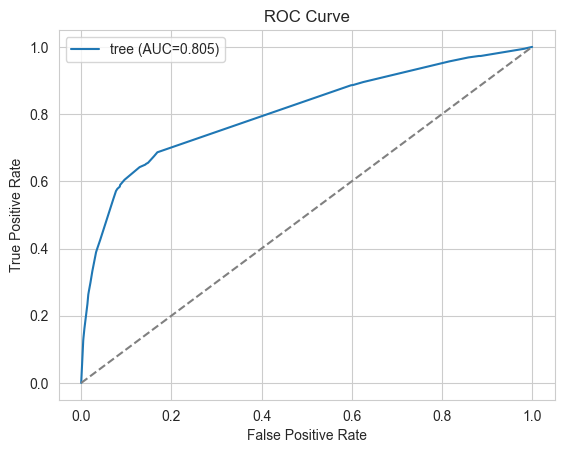

In [25]:
# Decision Tree
dt_model = create_pipeline(
    model=DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        max_leaf_nodes=35,
        class_weight='balanced',
        min_samples_leaf=50,
        criterion='entropy'
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=False,
    model_type='tree'
)
dt_model.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = "max_depth=8 + max_leaf_nodes=30 + class_weight='balanced  + min_samples_leaf=50 + criterion='entropy'"

# оцінка результатів
dt_results = evaluate_model('tree', dt_model,
                            X_train, y_train,
                            X_val, y_val,
                            dt_model.get_params(),
                            new_comment, dt_results)

In [93]:
# збереження та вивід таблиці результатів dt_results
save_results(dt_results, '../outputs/dt_results.csv')
dt_results = pd.read_csv('../outputs/dt_results.csv')
dt_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7441,0.7537,0.2943,0.2889,random_state=42 + max_depth=2
1,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7829,0.7913,0.3754,0.3652,max_depth=5
2,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8339,0.7580,0.5070,0.3991,max_depth=10
3,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8088,0.7893,0.4391,0.3756,max_depth=8
4,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7530,0.7633,0.3793,0.3792,max_depth=8 + max_leaf_nodes=10
5,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7880,0.7994,0.3894,0.3886,max_depth=8 + max_leaf_nodes=20
6,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7897,0.8001,0.3870,0.3798,max_depth=8 + max_leaf_nodes=30
7,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7953,0.7953,0.4616,0.4643,П.6 + class_weight='balanced'
8,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7956,0.8010,0.4572,0.4622,П.7 + min_samples_leaf=50
9,DT baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7952,0.8056,0.4643,0.4781,max_depth=8 + max_leaf_nodes=30 + class_weight...


**Таблиця порівнянням якості моделі** з різними налаштуваннями

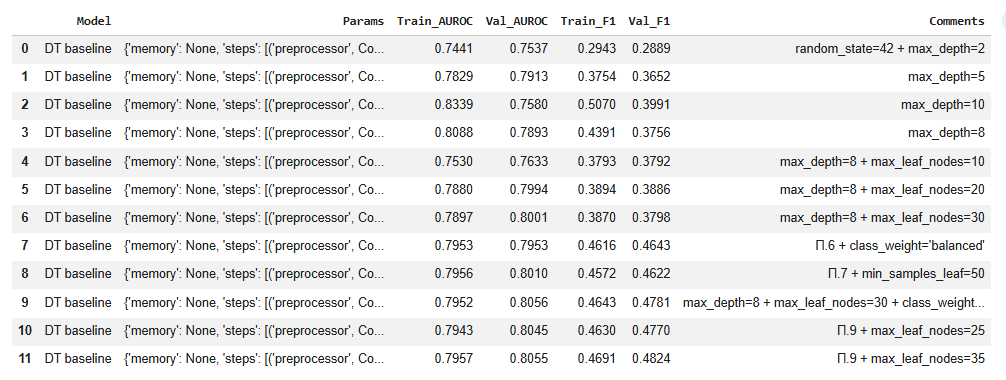

### **Висновки**

* Модель DecisionTree:

  * досягла найкращих результатів Val AUROC = 0.8056 при деяких налаштуваннях гіперпараметрів
  * показала кращі результати на валідації ніж модель логістичної регресії чи kNN: трохи краще узагальнює та ефективніше виділяє мінорний клас

* Потенційні кроки щодо подальшої роботи:
  - підбір оптимальних гіперпараметрів
  - підбір порогу класифікації
  - відбір найбільш впливовх та видалення "шумних" ознак

* Модель можна використовувати як базову, а також для інтерпретації та візуалізації

## XGBoost

### Базова модель

In [26]:
# формування даних
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)


=== xgbm ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7310
           1       0.69      0.24      0.35       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.65      8238
weighted avg       0.89      0.90      0.88      8238

Confusion matrix (validation):
[[7212   98]
 [ 709  219]]
Train AUROC: 0.8193
Validation AUROC: 0.815


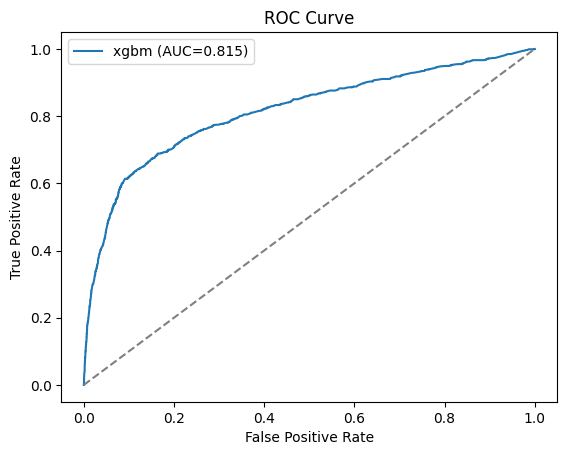

In [69]:
# XGBClassifie

xgbm_model = create_pipeline(
    model=XGBClassifier(
        n_estimators=10,
        max_depth=5,

        # learning_rate=0.03,
        # scale_pos_weight=7,      # для дисбалансу
        # subsample=0.8,           # частка рядків для кожного дерева

        # reg_lambda=1,            # L2 регуляризація
        # reg_alpha=0,              # L1 регуляризація

        # device='cuda',
        # verbosity=0,

        random_state=42,
        use_label_encoder=False,
        missing=np.nan),

    numeric_cols=num_features,
    categorical_cols=cat_features,
    scale_numeric=False,
    model_type='xgbm'
)
xgbm_model.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = 'n_estimators=10 + max_depth=5'

# оцінка результатів
xgbm_results = evaluate_model('xgbm', xgbm_model,
                              X_train, y_train,
                              X_val, y_val,
                              xgbm_model.get_params(),
                              new_comment, xgbm_results)

In [65]:
# збереження та вивід таблиці результатів xgbm_results
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,XGBM baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8193,0.8150,0.3763,0.3518,n_estimators=10 + max_depth=5
1,XGBM random search,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.8306,0.8170,0.5092,0.5301,Найкраща комбінація після Randomized Search
2,XGBM Hyperopt,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",0.8505,0.8151,0.5266,0.4789,Bayesian Optimization (Hyperopt)
3,XGBM Hyperopt,"{'n_estimators': 450, 'max_depth': 5, 'learnin...",0.8496,0.8168,0.5058,0.5149,Bayesian Optimization (Hyperopt)
4,XGBM Hyperopt,"{'n_estimators': 500, 'max_depth': 4, 'learnin...",0.8289,0.8151,0.4786,0.4924,Bayesian Optimization (Hyperopt)- 3
5,XGBM Hyperopt,"{'n_estimators': 700, 'max_depth': 4, 'learnin...",0.8308,0.8151,0.5037,0.5240,Bayesian Optimization (Hyperopt)- 4


**Найкращий результат XGBM з ручними налаштуваннями параметрів:**

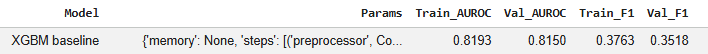



### RandomizedSearchCV

In [70]:
# формування даних
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)



=== XGBM random search ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.91      0.93      7310
           1       0.47      0.62      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.88      8238

Confusion matrix (validation):
[[6652  658]
 [ 356  572]]
Train AUROC: 0.8306
Validation AUROC: 0.817


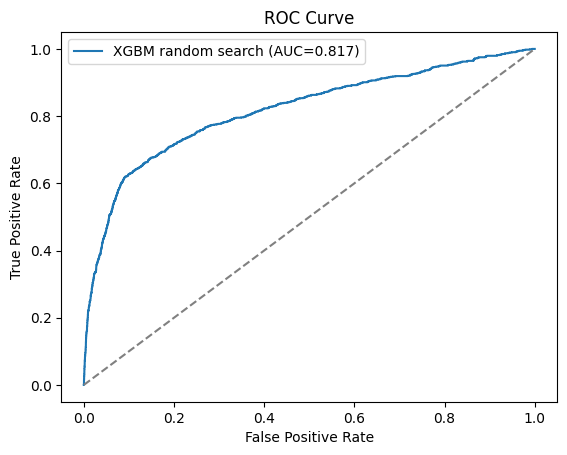

In [73]:
# модель з базовими технічними налаштуваннями
xgb_base = XGBClassifier(
    random_state=42,
    use_label_encoder=False)

# створення пайплайна для препроцесингу
pipeline_for_search = create_pipeline(
    model=xgb_base,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='xgbm',
    scale_numeric=True)

# сітка параметрів
param_dist = {
    'model__n_estimators': [500, 800],  # ітерації
    'model__learning_rate': [0.01, 0.05],  # крок
    'model__max_depth': [3, 4, 5],
    'model__scale_pos_weight': [5, 6, 7],  # баланс
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# пошук параметрів
random_search = RandomizedSearchCV(
    estimator=pipeline_for_search,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=20,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = 'Найкраща комбінація після Randomized Search'

# оцінка результатів
xgbm_results = evaluate_model(
    'XGBM random search',
    random_search.best_estimator_,
    X_train, y_train,
    X_val, y_val,
    random_search.best_params_,
    new_comment, xgbm_results
)

In [66]:
# збереження та вивід таблиці результатів xgbm_results
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,XGBM baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8193,0.8150,0.3763,0.3518,n_estimators=10 + max_depth=5
1,XGBM random search,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.8306,0.8170,0.5092,0.5301,Найкраща комбінація після Randomized Search
2,XGBM Hyperopt,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",0.8505,0.8151,0.5266,0.4789,Bayesian Optimization (Hyperopt)
3,XGBM Hyperopt,"{'n_estimators': 450, 'max_depth': 5, 'learnin...",0.8496,0.8168,0.5058,0.5149,Bayesian Optimization (Hyperopt)
4,XGBM Hyperopt,"{'n_estimators': 500, 'max_depth': 4, 'learnin...",0.8289,0.8151,0.4786,0.4924,Bayesian Optimization (Hyperopt)- 3
5,XGBM Hyperopt,"{'n_estimators': 700, 'max_depth': 4, 'learnin...",0.8308,0.8151,0.5037,0.5240,Bayesian Optimization (Hyperopt)- 4


**Найкращий результат XGBM після Randomized Search:**

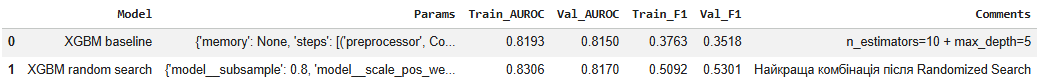

### Bayesian Optimization

In [74]:
# формування даних
train_xgbm = train_df.copy()
val_xgbm = val_df.copy()

input_cols_xgbm = [col for col in train_xgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_xgbm,
    val_df=val_xgbm,
    input_cols=input_cols_xgbm,
    target_col=target_col,
    drop_cols=drop_cols)


In [77]:
def objective(params):
    xgb_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': params['learning_rate'],
        'scale_pos_weight': params['scale_pos_weight'],
        'subsample': params['subsample'],
        'colsample_bytree': params['colsample_bytree'],
        'random_state': 42,
        'use_label_encoder': False,
        'n_jobs': -1
    }

    # модель з параметрами
    hyperopt_model = XGBClassifier(**xgb_params)

    # пайплайн
    hyperopt_pipeline = create_pipeline(
        model=hyperopt_model,
        numeric_cols=num_features,
        categorical_cols=cat_features,
        model_type='xgbm'
    )

    score = cross_val_score(hyperopt_pipeline, X_train, y_train, cv=5, scoring='roc_auc').mean()

    return {'loss': -score, 'status': STATUS_OK}

In [78]:
# space = {
#     'n_estimators': hp.quniform('n_estimators', 100, 1000, 50), # від 100 до 1000 з кроком 50
#     'max_depth': hp.quniform('max_depth', 3, 10, 1),           # від 3 до 10
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
#     'subsample': hp.uniform('subsample', 0.6, 1.0),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0)
# }

# space = {
#     'n_estimators': hp.quniform('n_estimators', 400, 1000, 50),
#     'max_depth': hp.quniform('max_depth', 3, 6, 1),
#     'learning_rate': hp.uniform('learning_rate', 0.01, 0.05),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 5, 8),
#     'subsample': hp.uniform('subsample', 0.7, 0.9),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.9),
#     'gamma': hp.uniform('gamma', 0.1, 0.5),
#     'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1)
# }


# space = {
#     'n_estimators': hp.quniform('n_estimators', 400, 1200, 50),
#     'max_depth': hp.quniform('max_depth', 3, 5, 1),
#     'learning_rate': hp.uniform('learning_rate', 0.005, 0.03),
#     'scale_pos_weight': hp.uniform('scale_pos_weight', 5.5, 7.5),
#     'subsample': hp.uniform('subsample', 0.6, 0.8),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 0.8),
#     'reg_alpha': hp.uniform('reg_alpha', 0.1, 10),             # L1
#     'reg_lambda': hp.uniform('reg_lambda', 1, 10),             # L2
#     'gamma': hp.uniform('gamma', 0.2, 1.0),
#     'min_child_weight': hp.quniform('min_child_weight', 5, 20, 1)
# }

space = {
    'n_estimators': hp.quniform('n_estimators', 300, 900, 50),

    'max_depth': hp.quniform('max_depth', 3, 7, 1),

    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.1)),

    'subsample': hp.uniform('subsample', 0.7, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 1.0),

    'min_child_weight': hp.quniform('min_child_weight', 1, 8, 1),

    'gamma': hp.uniform('gamma', 0, 0.4),

    'reg_alpha': hp.uniform('reg_alpha', 0, 3),
    'reg_lambda': hp.uniform('reg_lambda', 1, 5),

    'scale_pos_weight': hp.uniform('scale_pos_weight', 3, 8)
}

In [79]:
# об'єкт для збереження історії всіх спроб
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)
)

print('Найкращі параметри:', best)

100%|██████████| 20/20 [06:44<00:00, 20.25s/trial, best loss: -0.7967960239987169]
Найкращі параметри: {'colsample_bytree': np.float64(0.885215784922313), 'gamma': np.float64(0.20177961203084702), 'learning_rate': np.float64(0.012218946127659374), 'max_depth': np.float64(4.0), 'min_child_weight': np.float64(6.0), 'n_estimators': np.float64(700.0), 'reg_alpha': np.float64(2.1124021707183918), 'reg_lambda': np.float64(2.739991814603225), 'scale_pos_weight': np.float64(5.402785843556206), 'subsample': np.float64(0.7975097178206423)}



=== XGBM Hyperopt ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      7310
           1       0.45      0.62      0.52       928

    accuracy                           0.87      8238
   macro avg       0.70      0.76      0.73      8238
weighted avg       0.89      0.87      0.88      8238

Confusion matrix (validation):
[[6610  700]
 [ 350  578]]
Train AUROC: 0.8308
Validation AUROC: 0.8151


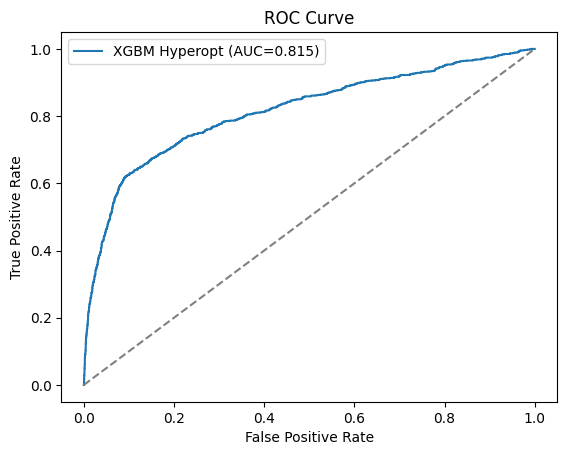

In [80]:
# підготовка параметрів
best_params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': int(best['max_depth']),
    'learning_rate': best['learning_rate'],
    'colsample_bytree': best['colsample_bytree'],
    'subsample': best['subsample'],
    'scale_pos_weight': best['scale_pos_weight'],
    'random_state': 42,
    'use_label_encoder': False
}

# фінальний пайплайн з найкращими параметрами
final_xgb = XGBClassifier(**best_params)

final_xgb_pipeline = create_pipeline(
    model=final_xgb,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='xgbm'
)

final_xgb_pipeline.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = 'Bayesian Optimization (Hyperopt)- 4'

# оцінка результатів
xgbm_results = evaluate_model(
    'XGBM Hyperopt',
    final_xgb_pipeline,
    X_train, y_train,
    X_val, y_val,
    best_params,
    new_comment,
    xgbm_results
)

In [132]:
# збереження та вивід таблиці результатів xgbm_results
save_results(xgbm_results, '../outputs/xgbm_results.csv')
xgbm_results = pd.read_csv('../outputs/xgbm_results.csv')
xgbm_results


,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,XGBM baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8193,0.8150,0.3763,0.3518,n_estimators=10 + max_depth=5
1,XGBM random search,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.8306,0.8170,0.5092,0.5301,Найкраща комбінація після Randomized Search
2,XGBM Hyperopt,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",0.8505,0.8151,0.5266,0.4789,Bayesian Optimization (Hyperopt)
3,XGBM Hyperopt,"{'n_estimators': 450, 'max_depth': 5, 'learnin...",0.8496,0.8168,0.5058,0.5149,Bayesian Optimization (Hyperopt)
4,XGBM Hyperopt,"{'n_estimators': 500, 'max_depth': 4, 'learnin...",0.8289,0.8151,0.4786,0.4924,Bayesian Optimization (Hyperopt)- 3
5,XGBM Hyperopt,"{'n_estimators': 700, 'max_depth': 4, 'learnin...",0.8308,0.8151,0.5037,0.5240,Bayesian Optimization (Hyperopt)- 4


**Найкращий результат XGBM після Bayesian Optimization:**

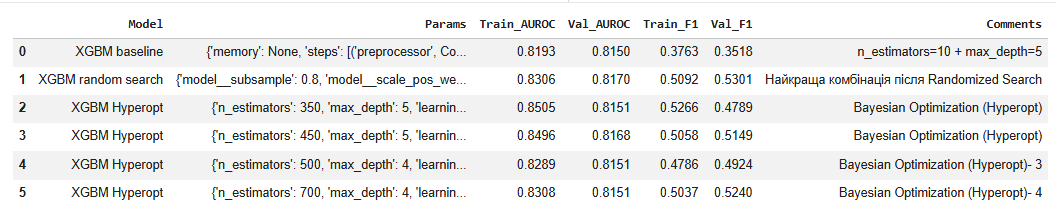


### **Висновки**
* Базова модель XGBM продемонструвала результат Val_AUROC = 0.8150, що свідчить про доволі хороші узагальнюючі властивості, але все ще не дуже якісне виділення мінорного класу: f1-score = 0.3518.

* Використання Randomized Search дозволило знайти параметри, при яких хоч і несуттєво, але покращився Val_AUROC (=0.8170) та значно зріс f1-score: 0.5301

* Пошук гіперпараметрів за допомогою Bayesian Optimization (Hyperopt) не дав суттєвого покращення в порівнянні з Randomized Search: Val_AUROC незначно зменшився, а f1-score коливається в межах 0.4789 -0.5240. Результати кращі, ніж у базової моделі XGBM.

* Для подальшого покращення моделі можна спробувати feature engineering та підбір порогу класифікації threshold

* В цілому XGBM-модель продемонструвала:
  -  найкращі результати з-поміж усіх попередніх моделей навіть з базовими налаштуваннями
  - стабільний  Val_AUROC та найвищий f1-score (при використанні Randomized Search)


## LightGBM

### Базова модель

In [ ]:
# формування даних
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

In [238]:
# Експерименти з Feature Engineering

# for df in [train_lgbm, val_lgbm]:
# # чи був контакт із клієнтом раніше (999 - відсутність контакту)
# df['new_customer'] = (df['pdays'] == 999).astype(int)

# # співвідношення контактів поточної кампанії до попередніх
# df['campaign_ratio'] = df['campaign'] / (df['previous'] + 1)

# успішний результат в минулому
# df['prev_success'] = (df['poutcome'] == 'success').astype(int)


# # індекс споживчих цін та довіри
# df['eco_index'] = df['cons.price.idx'] * df['cons.conf.idx']

# "ризиковані" клієнти
# df['is_high_risk'] = ((df['job'].isin(['unemployed', 'unknown'])) |
#                       (df['education'] == 'illiterate')).astype(int)


# # інтенсивність контактів
# df['high_contact_intensity'] = (df['campaign'] > 5).astype(int)

# # перший контакт
# df['is_first_contact'] = (df['campaign'] == 1).astype(int)

# # студент або пенсіонер
# df['is_student_or_retired'] = df['job'].isin(['student', 'retired']).astype(int)

# # вища освіта
# df['has_high_education'] = (df['education'] == 'university.degree').astype(int)

# # одинокий клієнт
# df['is_single'] = (df['marital'] == 'single').astype(int)


# # був контакт і він був успішним
# df['high_interest_client'] = (
#     (df['previous'] > 0) & (df['poutcome'] == 'success')
# ).astype(int)

# низька ставка
# df['low_interest_rate'] = (df['euribor3m'] < 2).astype(int)

In [254]:
input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [256]:
# LightGBM

# baseline: random_state=42, n_estimators=100, learning_rate=0.1, max_depth=-1,

lgbm_model = create_pipeline(
    model=LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=-1,
        is_unbalance=True,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),

    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
)

lgbm_model.fit(X_train, y_train)



[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004332 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 417
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('model',
                 LGBMClassifier(is_unbalance=True, learning_rate=0.05,
                                random_state=42, reg_alpha=0.1,
                                reg_lambda=0.1))])


=== LightGBM ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.41      0.66      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Confusion matrix (validation):
[[6435  875]
 [ 319  609]]
Train AUROC: 0.8526
Validation AUROC: 0.8202


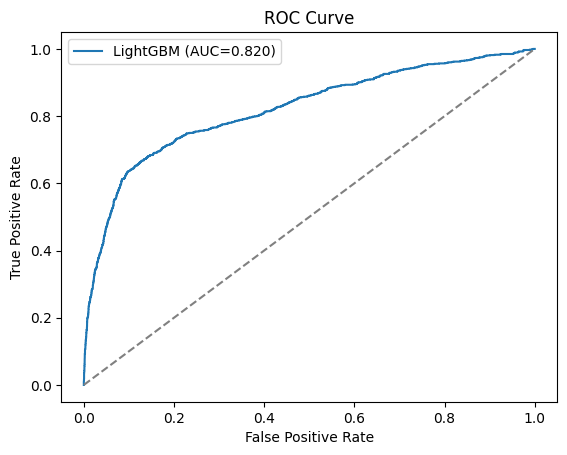

In [257]:
# коментар до таблиці результатів
new_comment = "П3 + drop'loan'"

# оцінка результатів
lgbm_results = evaluate_model(
    model_name='LightGBM',
    model=lgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params=lgbm_model.get_params(),
    comments=new_comment,
    results_table=lgbm_results
)

In [ ]:
# збереження та вивід таблиці результатів lgbm_results
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

**Найкращий результат LightGBM з ручними налаштуваннями параметрів:**

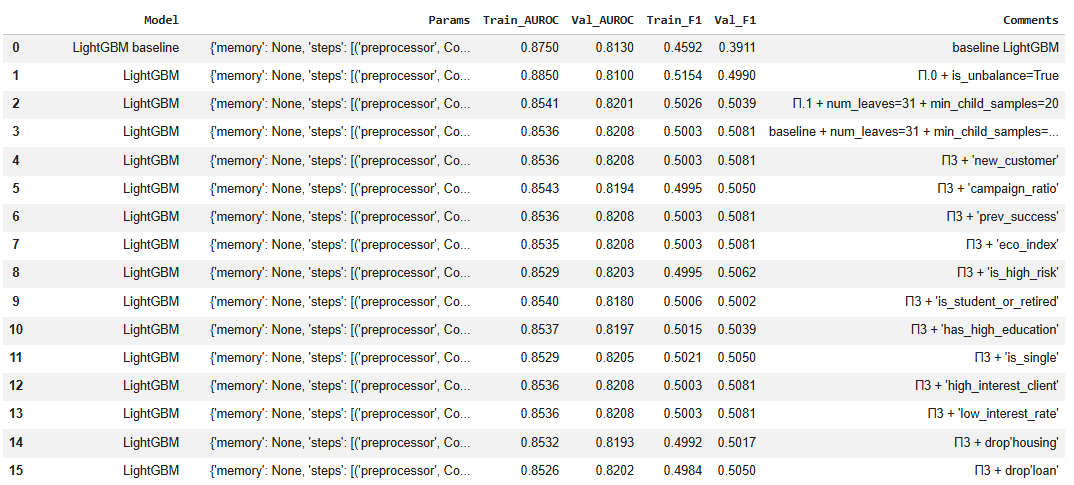

### Randomized Search

In [261]:
# формування даних
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)


=== LightGBM random search ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.43      0.64      0.52       928

    accuracy                           0.86      8238
   macro avg       0.69      0.77      0.72      8238
weighted avg       0.89      0.86      0.88      8238

Confusion matrix (validation):
[[6529  781]
 [ 332  596]]
Train AUROC: 0.8338
Validation AUROC: 0.8198


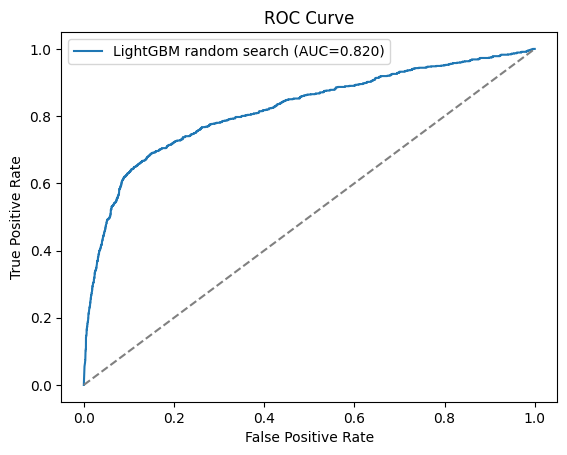

In [269]:
# базова модель
lgbm_base = LGBMClassifier(
    random_state=42,
    verbosity=-1
)

# пайплайн
pipeline_lgbm_search = create_pipeline(
    model=lgbm_base,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
    scale_numeric=True
)

# сітка параметрів
# param_dist_lgbm = {
#     'model__n_estimators': [100, 500, 1000],
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__num_leaves': [20, 31, 60],
#     'model__max_depth': [-1, 5, 10],
#     'model__min_child_samples': [10, 20, 50],
#     'model__is_unbalance': [True],
#     'model__reg_alpha': [0, 0.1, 0.5],
#     'model__reg_lambda': [0, 0.1, 0.5]
# }

param_dist_lgbm = {
    # 1. Співвідношення швидкості та кількості ітерацій
    'model__n_estimators': [500, 1000, 1500],
    'model__learning_rate': [0.005, 0.01, 0.05],

    'model__num_leaves': [15, 31, 63, 127],
    'model__max_depth': [-1, 5, 7, 9],
    'model__min_child_samples': [20, 50, 100],
    'model__reg_alpha': [0, 0.1, 1.0, 10.0],  # L1
    'model__reg_lambda': [0, 0.1, 1.0, 10.0],  # L2

    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__subsample': [0.7, 0.8, 0.9],

    'model__is_unbalance': [True]  # баланс класів
}

# пошук
random_search_lgbm = RandomizedSearchCV(
    estimator=pipeline_lgbm_search,
    param_distributions=param_dist_lgbm,
    n_iter=20,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search_lgbm.fit(X_train, y_train)

# коментар до таблиці результатів
new_comment = 'Результат після Randomized Search'

# оцінка результатів
lgbm_results = evaluate_model(
    "LightGBM random search",
    random_search_lgbm.best_estimator_,
    X_train, y_train,
    X_val, y_val,
    random_search_lgbm.best_params_,
    new_comment,
    lgbm_results
)

In [ ]:
# збереження та вивід таблиці результатів lgbm_results
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

.**Найкращий результат LightGBM після Random Search:**

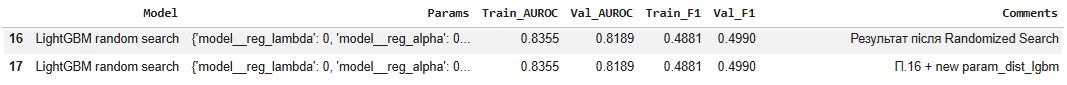

### Bayesian Optimization

In [287]:
# формування даних
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [289]:
def objective(params):
    lgbm_params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples']),
        'learning_rate': params['learning_rate'],
        'colsample_bytree': params['colsample_bytree'],
        'subsample': params['subsample'],
        'subsample_freq': int(params['subsample_freq']),
        'min_split_gain': params['min_split_gain'],
        'reg_alpha': params['reg_alpha'],
        'reg_lambda': params['reg_lambda'],
        'scale_pos_weight': params['scale_pos_weight'],

        'random_state': 42,
        'n_jobs': -1,
        'verbosity': -1,
    }

    # модель
    hyperopt_model = LGBMClassifier(**lgbm_params)

    # пайплайн
    hyperopt_pipeline = create_pipeline(
        model=hyperopt_model,
        numeric_cols=num_features,
        categorical_cols=cat_features,
        model_type='lightgbm'
    )

    score = cross_val_score(hyperopt_pipeline, X_train, y_train, cv=10, scoring='roc_auc').mean()

    return {'loss': -score, 'status': STATUS_OK}

In [290]:
# gростір пошуку гіперпараметрів
# space = {
#     'n_estimators': hp.quniform('n_estimators', 300, 1000, 50),
#     'max_depth': hp.quniform('max_depth', 3, 10, 1),
#     'num_leaves': hp.quniform('num_leaves', 20, 150, 1), # Головний параметр LGBM
#     'learning_rate': hp.loguniform('learning_rate', np.log(0.005), np.log(0.1)),
#     'subsample': hp.uniform('subsample', 0.6, 1.0),
#     'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
#     'min_child_samples': hp.quniform('min_child_samples', 5, 50, 5), # Аналог min_child_weight
#     'reg_alpha': hp.uniform('reg_alpha', 0, 10),
#     'reg_lambda': hp.uniform('reg_lambda', 0, 10)
# }


space = {
    'n_estimators': hp.quniform('n_estimators', 300, 1500, 50),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'num_leaves': hp.quniform('num_leaves', 15, 100, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.003), np.log(0.1)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'subsample_freq': hp.quniform('subsample_freq', 1, 10, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'min_child_samples': hp.quniform('min_child_samples', 5, 50, 5),
    'min_split_gain': hp.uniform('min_split_gain', 0.0, 1.0),
    'reg_alpha': hp.uniform('reg_alpha', 0, 10),
    'reg_lambda': hp.uniform('reg_lambda', 0, 10),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 5, 15)
}

In [291]:
# об'єкт для збереження історії всіх спроб
trials = Trials()

best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=40,  # Збільшив до 40, щоб Байєс встиг "навчитися"
    trials=trials,
    rstate=np.random.default_rng(42)
)

print('Найкращі параметри:', best)

100%|██████████| 40/40 [37:29<00:00, 56.24s/trial, best loss: -0.8013534465586734]
Найкращі параметри: {'colsample_bytree': np.float64(0.6044802705219741), 'learning_rate': np.float64(0.006463169636674099), 'max_depth': np.float64(5.0), 'min_child_samples': np.float64(15.0), 'min_split_gain': np.float64(0.9194741274816899), 'n_estimators': np.float64(1050.0), 'num_leaves': np.float64(99.0), 'reg_alpha': np.float64(2.557240383270325), 'reg_lambda': np.float64(3.0780459889893876), 'scale_pos_weight': np.float64(6.048306170464686), 'subsample': np.float64(0.8432609539640238), 'subsample_freq': np.float64(8.0)}


In [292]:
# підготовка параметрів
best_params = {
    'n_estimators': int(best['n_estimators']),
    'max_depth': int(best['max_depth']),
    'num_leaves': int(best['num_leaves']),
    'learning_rate': best['learning_rate'],
    'colsample_bytree': best['colsample_bytree'],
    'subsample': best['subsample'],
    'min_child_samples': int(best['min_child_samples']),
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'is_unbalance': True,
    'random_state': 42
}

# фінальний пайплайн з найкращими параметрами
final_lgbm = LGBMClassifier(**best_params)

final_lgbm_pipeline = create_pipeline(
    model=final_lgbm,
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm'
)

final_lgbm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy...
                                                   'poutcome'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=np.float64(0.6044802705219741),
                                is_unbalance=True,
                                learning_rate=np.float64(0.006463169636674099),
                                max_depth=5, min_child_samples=15,
                                n_estimators=1050, num_leaves=99,
                                random_state=42,
                                reg_alpha=np.float64(2.557240383270325),
                                reg_lambda=np.float64(3.0780459889893876),
                                subsample=np.float64(0.8432609539640238)))])


=== LGBM Hyperopt ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7310
           1       0.39      0.66      0.49       928

    accuracy                           0.84      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.84      0.86      8238

Confusion matrix (validation):
[[6343  967]
 [ 317  611]]
Train AUROC: 0.8304
Validation AUROC: 0.8174


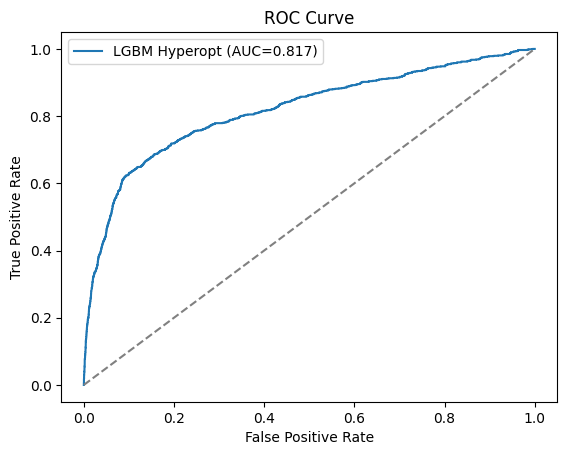

In [293]:
# коментар до таблиці результатів
new_comment = 'Bayesian Optimization + new space'

# оцінка результатів
lgbm_results = evaluate_model(
    'LGBM Hyperopt',
    final_lgbm_pipeline,
    X_train, y_train,
    X_val, y_val,
    best_params,
    new_comment,
    lgbm_results
)

In [299]:
# збереження та вивід таблиці результатів lgbm_results
save_results(lgbm_results, '../outputs/lgbm_results.csv')
lgbm_results = pd.read_csv('../outputs/lgbm_results.csv')
lgbm_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LightGBM baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.8750,0.8130,0.4592,0.3911,baseline LightGBM
1,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8850,0.8100,0.5154,0.4990,П.0 + is_unbalance=True
2,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8541,0.8201,0.5026,0.5039,П.1 + num_leaves=31 + min_child_samples=20
3,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8536,0.8208,0.5003,0.5081,baseline + num_leaves=31 + min_child_samples=...
4,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8536,0.8208,0.5003,0.5081,П3 + 'new_customer'
5,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8543,0.8194,0.4995,0.5050,П3 + 'campaign_ratio'
6,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8536,0.8208,0.5003,0.5081,П3 + 'prev_success'
7,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8535,0.8208,0.5003,0.5081,П3 + 'eco_index'
8,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8529,0.8203,0.4995,0.5062,П3 + 'is_high_risk'
9,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8540,0.8180,0.5006,0.5002,П3 + 'is_student_or_retired'


**Найкращий результат LightGBM після Bayesian Optimization:**
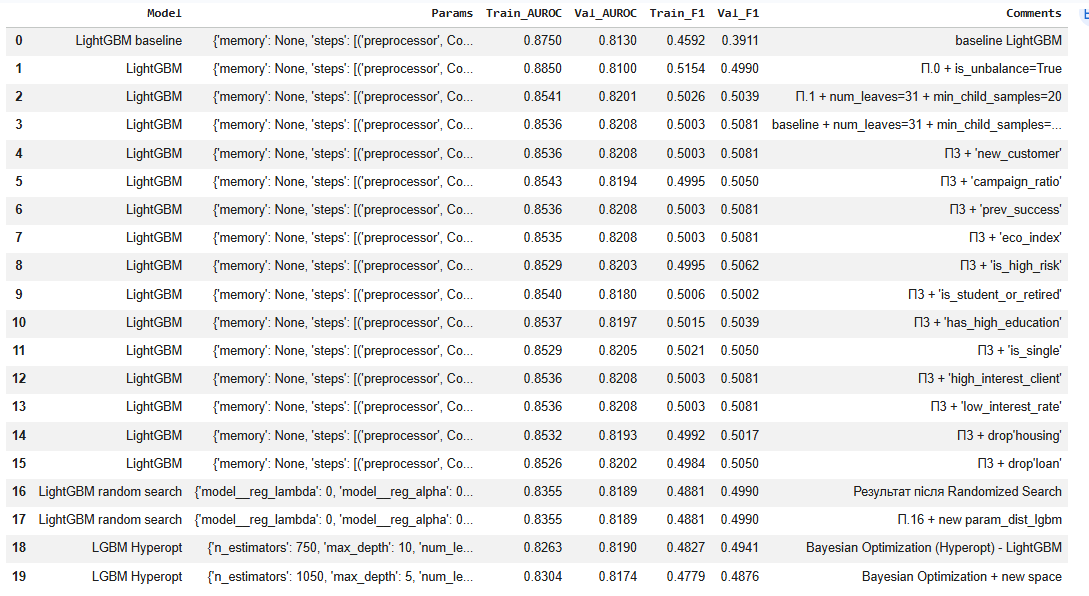

### **Висновки**
* Базова модель LightGBM з простими налаштуваннями продемонструвала результат Val_AUROC = 0.8208, що свідчить про доволі хороші узагальнюючі властивості, виділення мінорного класу також краще за попередні моделі: f1-score = 0.5081.

* Використання Randomized Search та Bayesian Optimization для пошуку гіперпараметрів не продемонструвало суттєвих змін, що свідчить про стабільну роботу моделі.

* Для подальшого покращення моделі можна спробувати feature engineering та підбір порогу класифікації threshold

* LightGBM-модель продемонструвала:
  -  найкращі результати з-поміж усіх попередніх моделей навіть з базовими налаштуваннями
  - стабільний  Val_AUROC та найвищий f1-score

## Загальна таблиця результатів роботи усіх моделей main_results

Для кожного алгоритму було обрано модель з найкращим значенням метрики на валідаційній вибірці. Отримані моделі зведені в узагальнюючу таблицю для подальшого порівняння.

In [300]:
# визначення найкращих результатів з-поміж всіх моделей
best_logreg = logreg_results.loc[logreg_results['Val_AUROC'].idxmax()]
best_knn = knn_results.loc[knn_results['Val_AUROC'].idxmax()]
best_dt = dt_results.loc[dt_results['Val_AUROC'].idxmax()]
best_xgbm = xgbm_results.loc[xgbm_results['Val_AUROC'].idxmax()]
best_lgbm = lgbm_results.loc[lgbm_results['Val_AUROC'].idxmax()]

# головна таблиця результатів
main_results = pd.DataFrame([best_logreg, best_knn, best_dt, best_xgbm, best_lgbm])
main_results = main_results.reset_index(drop=True)

main_results

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LogReg baseline,"{'memory': None, 'steps': [('preprocessor', Co...",0.7954,0.8015,0.4543,0.4665,max_iter=1000 + C=5 + liblinear + l1 + 'was_co...
1,knn,"{'memory': None, 'steps': [('preprocessor', Co...",0.8116,0.7912,0.3226,0.3141,"n=100, weights='uniform', metric='euclidean'"
2,tree,"{'memory': None, 'steps': [('preprocessor', Co...",0.7957,0.8055,0.4691,0.4824,max_depth=8 + max_leaf_nodes=30 + class_weight...
3,XGBM random search,"{'model__subsample': 0.8, 'model__scale_pos_we...",0.8306,0.8170,0.5092,0.5301,Найкраща комбінація після Randomized Search
4,LightGBM,"{'memory': None, 'steps': [('preprocessor', Co...",0.8536,0.8208,0.5003,0.5081,baseline + num_leaves=31 + min_child_samples=...


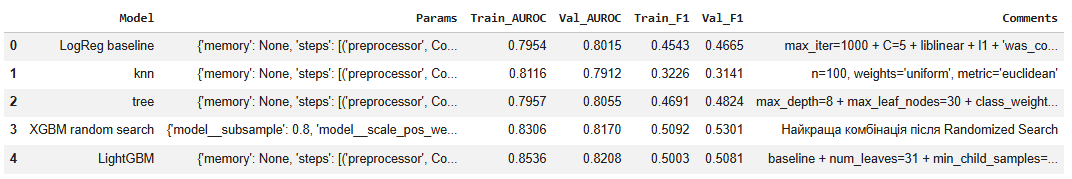

З огляду на те, що AUROC обрано як основну метрику оцінки, саме модель **LightGBM** була обрана як фінальна.

# Аналіз обраної фінальної моделі

In [27]:
# формування даних
train_lgbm = train_df.copy()
val_lgbm = val_df.copy()

input_cols_lgbm = [col for col in train_lgbm.columns if col not in ['y', 'y_num']]
drop_cols = ['duration']

X_train, y_train, X_val, y_val, num_features, cat_features = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_lgbm,
    target_col=target_col,
    drop_cols=drop_cols)

In [28]:
# модель
lgbm_model = create_pipeline(
    model=LGBMClassifier(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=-1,
        is_unbalance=True,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0.1
    ),
    numeric_cols=num_features,
    categorical_cols=cat_features,
    model_type='lightgbm',
)

lgbm_model.fit(X_train, y_train)



[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018542 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co


=== LightGBM ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      7310
           1       0.41      0.66      0.51       928

    accuracy                           0.86      8238
   macro avg       0.68      0.77      0.71      8238
weighted avg       0.89      0.86      0.87      8238

Confusion matrix (validation):
[[6441  869]
 [ 316  612]]
Train AUROC: 0.8536
Validation AUROC: 0.8208


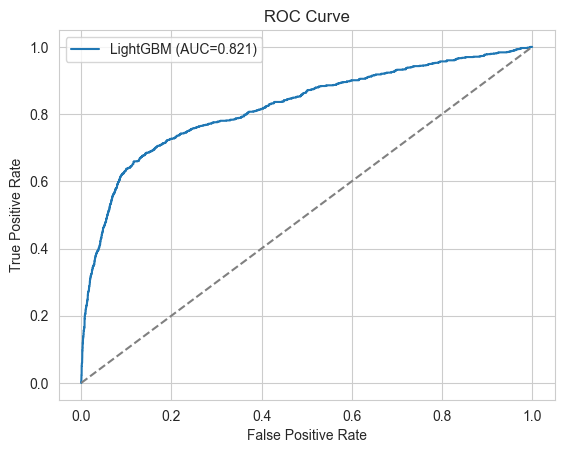

In [29]:
# коментар до таблиці результатів
new_comment = 'Найкраща модель'

# оцінка результатів
lgbm_results = evaluate_model(
    model_name='LightGBM',
    model=lgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    params=lgbm_model.get_params(),
    comments=new_comment,
    results_table=lgbm_results
)

In [30]:
# підбір thresholds

y_val_proba = lgbm_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_val_proba >= t).astype(int)

    f1 = f1_score(y_val, y_pred)

    results.append({
        'threshold': round(t, 2),
        'f1_score': f1
    })

threshold_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False)

threshold_df

,threshold,f1_score
11,0.65,0.531041
10,0.60,0.529546
12,0.70,0.529032
9,0.55,0.524298
13,0.75,0.520231
8,0.50,0.508095
7,0.45,0.482916
14,0.80,0.472050
6,0.40,0.441678
15,0.85,0.404207


In [31]:
# найкращий поріг класифікації
best_threshold = threshold_df.iloc[0]['threshold']
best_threshold

np.float64(0.65)

In [32]:
# фінальні метрики при best_threshold
y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)

print(classification_report(y_val, y_val_pred_opt))
print('F1:', f1_score(y_val, y_val_pred_opt))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      7310
           1       0.48      0.60      0.53       928

    accuracy                           0.88      8238
   macro avg       0.71      0.76      0.73      8238
weighted avg       0.89      0.88      0.89      8238

F1: 0.5310410697230181


Додатково проведено підбір порогу класифікації, що дозволило змінити додаткові метрики при threshold=0.65:
 * Precision зріз від 0.41 до 0.48, отже зменшилась кількість хибнопозитивних випадків
 * водночас Recall зменшився з 0.66 до 0.60, тобто зменшилась кількість істинно позитивних випадків
 * F1-score збільшився від 0.51 до 0.53, що робить модель більш збалансованою
 * метрики accuracy, macro avg F1 та weighted avg також зросли.

# Аналіз впливу ознак

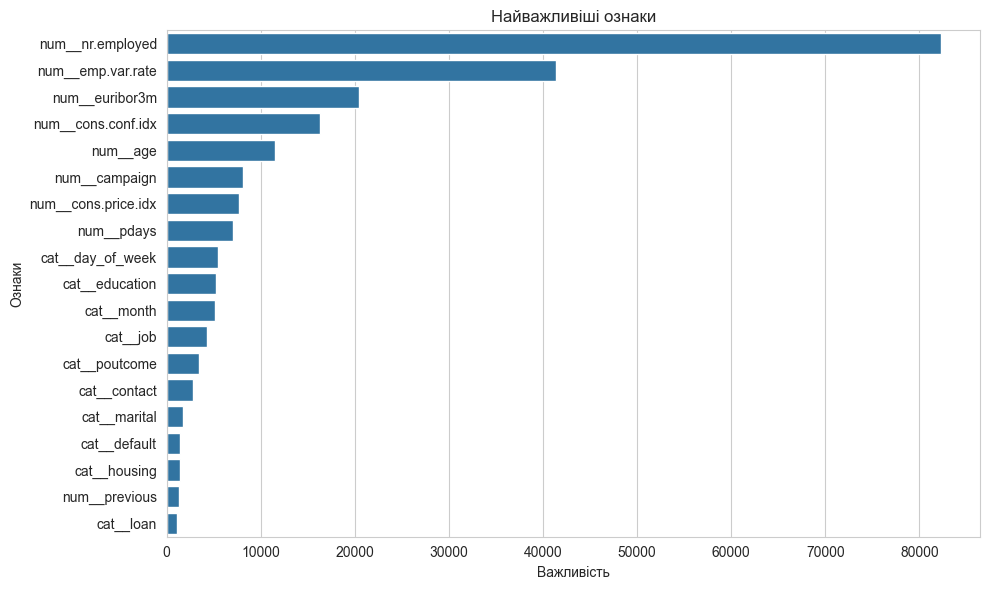

                feature    importance
8      num__nr.employed  82329.560008
4     num__emp.var.rate  41421.052789
7        num__euribor3m  20414.570851
6    num__cons.conf.idx  16283.818325
0              num__age  11542.886812
1         num__campaign   8156.252904
5   num__cons.price.idx   7662.073243
2            num__pdays   7104.807400
17     cat__day_of_week   5450.220417
11       cat__education   5214.864899
16           cat__month   5170.822080
9              cat__job   4300.484853
18        cat__poutcome   3390.188483
15         cat__contact   2839.310398
10         cat__marital   1787.972493
12         cat__default   1435.223952
13         cat__housing   1429.530117
3         num__previous   1312.327377
14            cat__loan   1129.229440


In [32]:
# ознаки після препроцесингу
feature_names = lgbm_model.named_steps['preprocessor'].get_feature_names_out()

# моодель LightGBM
booster = lgbm_model.named_steps['model']

importance = booster.booster_.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

importance_df = importance_df.sort_values(by='importance', ascending=False)

# топ ознак
top_features = importance_df.head(20)

# візуалізація
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature'
)
plt.title('Найважливіші ознаки')
plt.xlabel('Важливість')
plt.ylabel('Ознаки')
plt.tight_layout()
plt.show()

print(top_features)

Графік важливості ознак

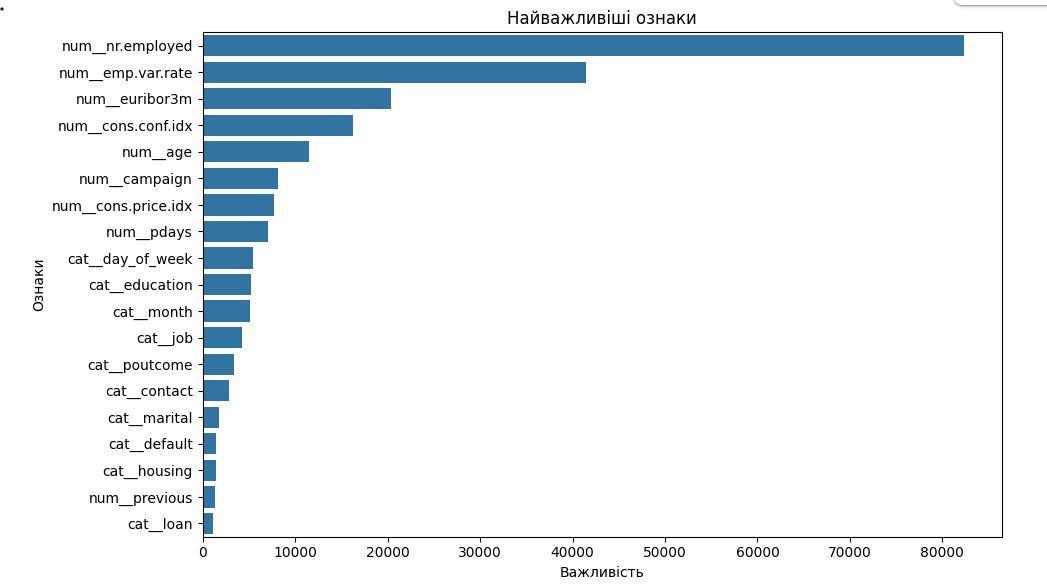

На основі графіка важливості ознак для моделі LightGBM можна зробити такі висновки:

* Найбільший внесок у прогноз має ознака 'nr.employed', важливість якої суттєво перевищує всі інші.
* Найбільш значний внесок у модель роблять макроекономічні показники: 'nr.employed', 'emp.var.rate', 'euribor3m' та 'cons.conf.idx'.
* Вік ('age') та інтенсивність контактів у межах поточної кампанії ('campaign') є найбільш важливими ознаками серед індивідуальних характеристик клієнта.
* Ознаки 'loan', 'housing', 'default' та 'previous' мають низьку важливість.

Аналіз важливості ознак загалом узгоджується з результатами EDA: суттєвий вплив мають макроекономічні показники та інтенсивність взаємодії з клієнтом. Отримані результати мають сенс і з точки зору бізнесу: економічний стан впливає на фінансові рішення клієнтів, а стратегія контактів може суттєво впливати на результат маркетингової кампанії.


## Додатковий аналіз

### Видалення ознаки 'nr.employed' для оцінки впливу кореляції між макроекономічними ознаками

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006528 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 409
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898

=== LGBM without nr.employed ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.68      0.28      0.39       928

    accuracy                           0.90      8238
   macro avg       0.80      0.63      0.67      8238
weighted avg       0.89      0.90      0.89      8238

Confusion matrix (validation):
[[7188  122]
 [ 

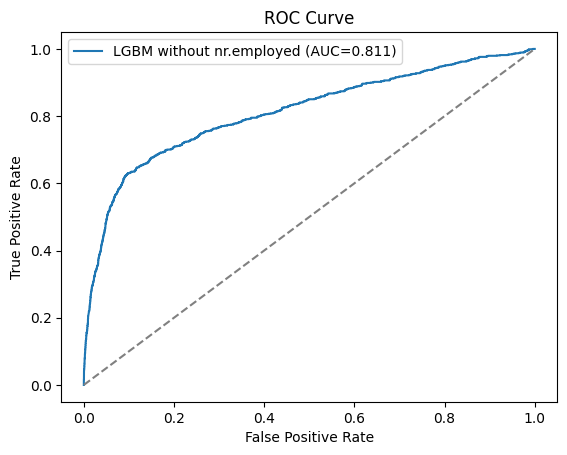

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LGBM without nr.employed,None,0.8748,0.8114,0.4579,0.3945,None


In [34]:
drop_feature = 'nr.employed'

# новий список колонок
input_cols_drop = [col for col in input_cols_lgbm if col != drop_feature]

X_train_d, y_train_d, X_val_d, y_val_d, num_f_d, cat_f_d = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_drop,
    target_col=target_col,
    drop_cols=drop_cols
)

# нова модель
lgbm_drop = create_pipeline(
    model=LGBMClassifier(random_state=42),
    numeric_cols=num_f_d,
    categorical_cols=cat_f_d,
    model_type='lightgbm'
)

lgbm_drop.fit(X_train_d, y_train_d)

evaluate_model(
    'LGBM without nr.employed',
    lgbm_drop,
    X_train_d, y_train_d,
    X_val_d, y_val_d
)

Видалення ознаки nr.employed не призвело до значного погіршення AUROC, що свідчить про те, що модель не є повністю залежною від цієї ознаки.
Водночас значне зниження F1-score вказує на те, що ця ознака має суттєвий вплив на фінальний прогноз (допомагає моделі краще виявляти позитивний клас).

### Видалення ознак 'nr.employed', 'emp.var.rate', 'euribor3m' для оцінки впливу кореляції між макроекономічними ознаками

[LightGBM] [Info] Number of positive: 3712, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 244
[LightGBM] [Info] Number of data points in the train set: 32950, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.112656 -> initscore=-2.063898
[LightGBM] [Info] Start training from score -2.063898

=== LGBM without nr.employed ===
Classification report (validation):
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7310
           1       0.66      0.25      0.36       928

    accuracy                           0.90      8238
   macro avg       0.79      0.61      0.65      8238
weighted avg       0.88      0.90      0.88      8238

Confusion matrix (validation):
[[7192  118]
 [ 

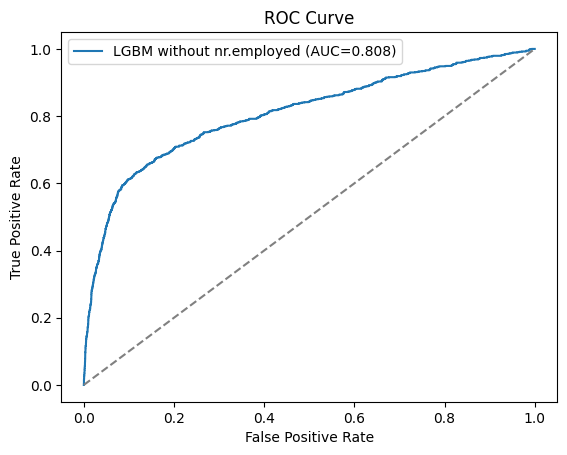

,Model,Params,Train_AUROC,Val_AUROC,Train_F1,Val_F1,Comments
0,LGBM without nr.employed,None,0.8655,0.8081,0.4627,0.3579,None


In [35]:
drop_features = ['nr.employed', 'emp.var.rate', 'euribor3m']

# новий список колонок
input_cols_drop = [col for col in input_cols_lgbm if col not in drop_features]

X_train_d, y_train_d, X_val_d, y_val_d, num_f_d, cat_f_d = prepare_data(
    train_df=train_lgbm,
    val_df=val_lgbm,
    input_cols=input_cols_drop,
    target_col=target_col,
    drop_cols=drop_cols
)

# нова модель
lgbm_drop = create_pipeline(
    model=LGBMClassifier(random_state=42),
    numeric_cols=num_f_d,
    categorical_cols=cat_f_d,
    model_type='lightgbm'
)

lgbm_drop.fit(X_train_d, y_train_d)

evaluate_model(
    'LGBM without nr.employed',
    lgbm_drop,
    X_train_d, y_train_d,
    X_val_d, y_val_d
)

Видалення основних макроекономічних ознак ('nr.employed', 'emp.var.rate', 'euribor3m') призвело до незначного зниження AUROC, що свідчить про збереження здатності моделі розрізняти класи.
Водночас спостерігається суттєве падіння F1-score, що вказує на важливу роль цих ознак у виявленні позитивного класу.

Отже, макроекономічні ознаки суттєво підвищують здатність моделі виявляти позитивний клас.

# SHAP-аналіз впливу ознак


Для інтерпретації моделі було використано бібліотеку SHAP, яка дозволяє оцінити внесок кожної ознаки, а також напрям впливу кожної ознаки - збільшення або зменшення ймовірності цільового класу.

 99%|===================| 8191/8238 [00:45<00:00]        

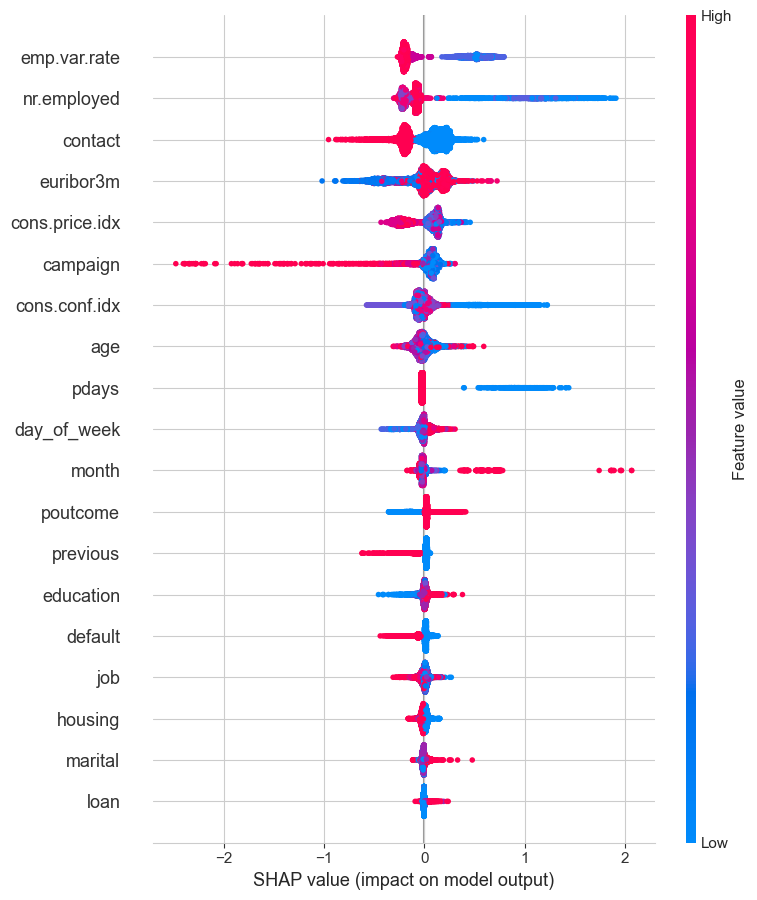

In [33]:
# найкраща модель
best_pipeline = lgbm_model

# препроцесинг
preprocessor = best_pipeline.named_steps['preprocessor']
X_val_transformed = preprocessor.transform(X_val)

# ознаки
feature_names = preprocessor.get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names]

# DataFrame для SHAP
X_val_disp = pd.DataFrame(X_val_transformed, columns=feature_names)

# модель
model = best_pipeline.named_steps['model']

# SHAP
explainer = shap.Explainer(model, X_val_transformed)
shap_values = explainer(X_val_transformed)

# візуалізація
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_val_disp)

**Висновки**

* Найбільший вплив на прогноз моделі мають макроекономічні показники Їхні значення суттєво змінюють передбачення моделі як у бік збільшення, так і зменшення ймовірності позитивного класу:
  - 'emp.var.rate': нижчі значення частіше підвищують ймовірність позитивного результату, вищі значення - знижують її
  - 'nr.employed': менша кількість зайнятих частіше співпадає з вищою ймовірністю позитивної відповіді, більша кількість зайнятих - з нижчою ймовірністю.
  - 'euribor3m': нижчі процентні ставки підвищують ймовірність позитивного результату, вищі - знижують її.
  - 'cons.conf.idx': нижчі значення індексу споживчої довіри частіше пов’язані з вищою ймовірністю позитивної відповіді, вищі значення - з нижчою.
* Інтенсивність контактів 'campaign' має помітний негативний вплив при великих значеннях, що може свідчити про "перенасичення" клієнтів комунікацією.
* Ознака 'pdays' вказуэ на те, що клієнти, з якими нещодавно контактували, мають вищу ймовірність позитивної відповіді.
* Категоріальні ознаки ('month', 'poutcome', 'contact') також впливають на результат, це відображає результати стратегії маркетингових кампаній.


# Аналіз записів, в яких модель помиляється

In [34]:
# передбачення
threshold = best_threshold

y_val_proba = lgbm_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= threshold).astype(int)

# істинні мітки, передбачені мітки, ймовірності
error_df = pd.DataFrame({
    'true_label': y_val,
    'pred_label': y_val_pred,
    'pred_proba': y_val_proba,
}, index=X_val.index)

error_df = error_df.join(val_df.drop(columns=['y', 'y_num']))

# типи помилок
error_df['error_type'] = 'correct'
error_df.loc[(error_df['true_label'] == 1) & (error_df['pred_label'] == 0), 'error_type'] = 'FN'
error_df.loc[(error_df['true_label'] == 0) & (error_df['pred_label'] == 1), 'error_type'] = 'FP'

# список числових ознак для аналізу (важливі)
num_cols = ['nr.employed', 'emp.var.rate', 'euribor3m', 'cons.conf.idx',
            'age', 'campaign', 'pdays']

# групування за типом помилки + середнє значення ознак
summary = error_df.groupby('error_type')[num_cols + ['pred_proba']].mean()

# підрахунок кількості значень
summary['count'] = error_df['error_type'].value_counts()

display(summary)

,nr.employed,emp.var.rate,euribor3m,cons.conf.idx,age,campaign,pdays,pred_proba,count
error_type,,,,,,,,,
FN,5171.878763,0.083065,3.574702,-41.899462,39.029570,2.534946,988.362903,0.353418,372
FP,5050.887705,-2.418852,1.053184,-37.755082,42.114754,1.855738,863.965574,0.801365,610
correct,5177.170783,0.298484,3.852724,-40.635226,39.944460,2.660832,971.350882,0.332774,7256


## **Висновки**
Модель:
* переоцінює ймовірність 'yes' і робить хибнопозитивні прогнози у хороших економічних умовах
* менш точно виявляє 'yes' у гірших умовах
* недооцінює позитивні випадки серед молодших клієнтів із відносно низькими економічними показниками

Для покращення моделі можна:
- відкорегувати поріг класифікації
- збалансувати дані
- додатково дослідити випадки з низькими значеннями 'euribor3m'
- додати ознаки, які краще описують економічне становище
- дослідити поведінку нових клієнтів, контакт з якими модель часто хибно вважає неуспішним
